In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
from pathlib import Path
from scipy.stats import gaussian_kde
import time

import torch
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import zuko

import utils

### 1. NLL-based permutation importance

Write the context vector as $\mathbf{x} = (x_k, \mathbf{x}_{-k})$ where $x_k$ is the single feature of interest (say, `COV_URBAN`) and $\mathbf{x}_{-k} \in \mathbb{R}^{20}$ is everything else.

When you run:

```python
Xp[:, k] = Xp[torch.randperm(len(Xp)), k]
```

you are drawing $x_k^{(i)}$ values from its marginal ditribution and pairing them with the original $(\mathbf{x}_{-k}^{(i)}, \mathbf{y}^{(i)})$. The resulting dataset has samples distributed as:

$$(\tilde{x}_k^{(i)}, \mathbf{x}_{-k}^{(i)}, \mathbf{y}^{(i)}) \sim \tilde{P}$$

The permutation operation breaks **both** the conditional dependence $X_k \mid \mathbf{X}_{-k}$ and the direct relationship $X_k \to \mathbf{Y}$. The resulting distribution $\tilde{P}$ is one where:

$$X_k \perp (\mathbf{X}_{-k}, \mathbf{Y})$$

In the permuted world, $X_k$ has nothing to do with anything. It is pure noise.

To get final scores we analyse Model Reliance on feature $k$, i.e. $\text{MR}(k)$:
$$\text{MR}(k) = \mathcal{L}{\text{perm}}^{(k)} - \mathcal{L}{\text{orig}}.$$

**Results interpretation:**

It indicates how much the model relies on the feature under consideration for its estimation, in particular how much a feature affects the mean.
$MR(k) = 2.4$ means: shuffling feature $k$ makes the model's probability assignments to actual target $2.4$ points worse w.r.t. the NLL.

In [2]:
def permutation_importance_full(flow, X, Y, feature_names, device, n=1000, n_repeats=15):
    """
    NLL-based permutation importance over ALL features.

    Uses n_repeats independent permutations to estimate mean and std.

    Parameters
    ----------
    flow       : trained zuko NSF
    X          : tensor of shape (N, n_feats) — standardized test features
    Y          : tensor of shape (N, n_target)       — standardized log-transformed targets
    feature_names : list of str, length n_feats
    device     : device on which we want to work
    n          : number of test samples to use
    n_repeats  : number of independent permutations per feature (Fisher et al. §3)

    Returns
    -------
    means : pd.Series  — mean NLL increase per feature
    stds  : pd.Series  — std of NLL increase (used for error bars)
    plots with error bars
    """
    # If Y is in the shape (N,) we transform in a matrix (N,1)
    if Y.ndim == 1:
        Y = Y.unsqueeze(-1)

    flow.eval()
    idx = torch.randperm(len(X))[:n]
    Xp = X[idx].clone()
    Yp = Y[idx]
    Xp = Xp.to(device)
    Yp = Yp.to(device)

    with torch.no_grad():
        base_nll = -flow(Xp).log_prob(Yp).mean().item()

    results = {}
    for k, feat in enumerate(feature_names):
        deltas = []
        for _ in range(n_repeats):
            Xp_perm = Xp.clone()
            # Independently permute only column k
            Xp_perm[:, k] = Xp[torch.randperm(len(Xp)), k]
            with torch.no_grad():
                perm_nll = -flow(Xp_perm).log_prob(Yp).mean().item()
            deltas.append(perm_nll - base_nll)
        results[feat] = (np.mean(deltas), np.std(deltas))

    means = pd.Series({k: v[0] for k, v in results.items()})
    stds  = pd.Series({k: v[1] for k, v in results.items()})

    # Plot with error bars
    order = means.sort_values(ascending=True)
    fig, ax = plt.subplots(figsize=(9, 7))
    ax.barh(order.index, order.values,
            xerr=stds[order.index].values, capsize=4,
            color=['steelblue' if v > 0 else 'lightgray' for v in order.values])
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel("Mean ΔNLL", fontsize=11)
    ax.set_title("Permutation Feature Importance — All Context Features\n"
                 f"({n_repeats} permutation trials, error bars = ± std)", fontsize=12)
    plt.tight_layout()
    plt.show()
    return means, stds


### 2 Integrated gradient

Based on two axioms:
- **Sensitivity** -> if the model output changes when you change a feature from baseline to actual value, that feature must receive non-zero attribution. (Simple gradients can fail this axiom at saturation points)

- **Implementation invariance** -> attribution for every feature must not depend on implementation details.

Now we can define the *Integrated Gradient* for feature $k$ at input $x$ with baseline $x^{'}$:
$$IG_k(x) = (x_k - x^{'}_k) × \int_{0}^{1} \biggl[\frac{\partial \log {p(y | x^{'} + \alpha(x-x^{'}))} } {\partial x_k}\biggr] d\alpha.$$
This is the path integral of the gradient along the straight line from baseline x' to actual input x.

**Propostion:** the sum of all integrated gradients equals the total log-likelihood difference between $x$ and $x^{'}$:
$$Σ_k IG_k(x) = \log {p(y|x)} -   \log {p(y|x^{'})}.$$

Now the problem is the choice of the baseline $x^{'}$. Let's try with the standardized mean (all zero).
(maybe we can also follow the strategies of the previous method and compute a permutation of all the values along the features).

Plain gradients can be misleading when the model is saturated — i.e., when the function is flat near x (small gradient) but still different from the baseline by a large amount. IG fixes this by integrating over the entire path, so it accounts for the fact that the function changed a lot somewhere between baseline and x even if it's locally flat.

Computing IG requires approximating a path integral, we have two ways to compute IG:
1. Scipy quad version:
    - it's computationally more expansive
    - use for case study analysis of a single specific disaster events (For the worst predicted disaster, which features drove that prediction?)
2. Riemann sum version:
    - regular analysis of the model across many test samples
    - getting feature importance rankings for the whole test set

**Results interpretation:**

Other method (like NLL-based permutation importance) tell us if the feature is globally important for the prediction of the target, while IG tells us if the feature typically increase the target probability, or it has a more heterogeneous effect (it increase it for some vents, while it decrease it for other), or it decrease the tarhet probability.

But IG does not tell us globally what is the weight of the feature in the target's prediction, so it has to be red combined with other metrics.

For example:
- high permutation $\Delta NLL$ + high avarage $IG$ $\Rightarrow$ Important globally + typically increases target probability
- high permutation $\Delta NLL$ + near zero avarage $IG$ $\Rightarrow$ Important globally but heterogeneous effect (+ for some events, - for others)
- near zero permutation $\Delta NLL$ + negative avarage $IG$ $\Rightarrow$ Not important globally, but when it matters, it reduces target probability
- near zero permutation $\Delta NLL$ + near zero avarage $IG$ $\Rightarrow$ Not important at all

In [3]:
# we can compute IG with high accuracy with scipy (computationally expansive)
# Very precise, to be used with only one sample

from scipy.integrate import quad

def integrated_gradients_scipy(flow, x, y, feature_names, device,
                                x_ref=None, limit=100):
    """
    High-accuracy IG using scipy's adaptive quadrature.
    Use for detailed analysis of individual events, not for batch processing.
    
    Parameters
    ----------
    flow          : trained zuko NSF
    x             : tensor (1, n_feats) — single context sample
    y             : tensor (1, n_targets) — single target sample
    feature_names : list of feature names
    device        : device for computations
    x_ref         : baseline (default: zeros)
    limit         : max subdivisions for quad (higher = more accurate)
    
    Returns
    -------
    s : pd.Series of IG attributions per feature
    """
    flow.eval()
    
    if x_ref is None:
        x_ref = torch.zeros(1, x.shape[1], device=device)
    else:
        x_ref = x_ref.to(device)
    
    x = x.to(device)
    y = y.to(device)
    
    if y.ndim == 1:
        y = y.unsqueeze(-1)
    
    x_np = x.cpu().numpy()
    x_ref_np = x_ref.cpu().numpy()
    
    ig_values = []
    
    for k in range(x.shape[1]):
        def integrand(alpha):
            x_path = x_ref_np + alpha * (x_np - x_ref_np)
            x_path_t = torch.tensor(x_path, dtype=torch.float32, 
                                   device=device, requires_grad=True)
            lp = flow(x_path_t).log_prob(y)
            lp.backward()
            return x_path_t.grad[0, k].item()
        
        integral, error = quad(integrand, 0.0, 1.0, limit=limit)
        ig_k = (x_np[0, k] - x_ref_np[0, k]) * integral
        ig_values.append(ig_k)
    
    s = pd.Series(ig_values, index=feature_names).sort_values(ascending=True)
    colors = ['steelblue' if v >= 0 else 'salmon' for v in s.values]
    
    fig, ax = plt.subplots(figsize=(9, 7))
    ax.barh(s.index, s.values, color=colors)
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel("Integrated Gradient attribution", fontsize=11)
    ax.set_title("Integrated Gradients (scipy adaptive quadrature)\n"
                 "High-accuracy single-sample analysis", fontsize=11)
    plt.tight_layout()
    plt.show()
    
    return s
 

In [4]:
def integrated_gradients(flow, X, Y, feature_names, device,
                         x_ref=None, n_steps=300, n_context=300):
    """
    Integrated gradients attribution along path from baseline to actual input.
    
    Parameters
    ----------
    flow          : trained zuko NSF
    X             : tensor (N, n_feats) — standardized test features
    Y             : tensor (N, n_targets) — standardized targets
    feature_names : list of feature names
    device        : device for computations
    x_ref         : baseline context (default: zeros = mean in standardized space)
    n_steps       : number of Riemann sum steps for path integral
    n_context     : number of test samples to average over
    
    Returns
    -------
    s : pd.Series of IG attributions per feature
    """
    flow.eval()
    
    if x_ref is None:
        x_ref = torch.zeros(1, X.shape[1], device=device)
    else:
        x_ref = x_ref.to(device)
    
    n_context = min(n_context, len(X))
    idx = torch.randperm(len(X))[:n_context]
    Xs = X[idx].to(device)
    Ys = Y[idx].to(device)
    
    # Ensure Y has correct shape
    if Ys.ndim == 1:
        Ys = Ys.unsqueeze(-1)
    
    alphas = torch.linspace(0, 1, n_steps, device=device)
    total_ig = torch.zeros(X.shape[1], device=device)
    
    for i in range(n_context):
        x_i = Xs[i:i+1]
        y_i = Ys[i:i+1]
        
        # Interpolate along path from baseline to x_i
        path = x_ref + alphas.unsqueeze(1) * (x_i - x_ref)  # (n_steps, n_feats)
        path.requires_grad_(True)
        
        # Compute gradients along entire path at once
        y_expanded = y_i.expand(n_steps, -1)
        lp = flow(path).log_prob(y_expanded)
        lp.sum().backward()
        
        # Riemann sum approximation of integral
        grads = path.grad
        ig_i = (x_i - x_ref).squeeze(0) * grads.mean(0)
        total_ig += ig_i.detach()
    
    ig_mean = (total_ig / n_context).cpu().numpy()
    
    s = pd.Series(ig_mean, index=feature_names).sort_values(ascending=True)
    colors = ['steelblue' if v >= 0 else 'salmon' for v in s.values]
    
    fig, ax = plt.subplots(figsize=(9, 7))
    ax.barh(s.index, s.values, color=colors)
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel("Integrated Gradient attribution", fontsize=11)
    ax.set_title(f"Integrated Gradients\n"
                 f"{n_steps} steps, {n_context} samples", fontsize=11)
    plt.tight_layout()
    plt.show()
    
    return s


def verify_ig_completeness(flow, X, Y, ig_values, device, x_ref=None, n_check=50):
    """
    Verifies that sum of IGs equals log p(y|x) - log p(y|x_ref).
    If relative error > 5%, increase n_steps.
    """
    flow.eval()
    
    if x_ref is None:
        x_ref = torch.zeros(1, X.shape[1], device=device)
    else:
        x_ref = x_ref.to(device)
    
    n_check = min(n_check, len(X))
    idx = torch.randperm(len(X))[:n_check]
    Xs = X[idx].to(device)
    Ys = Y[idx].to(device)
    
    if Ys.ndim == 1:
        Ys = Ys.unsqueeze(-1)
    
    ig_sum = sum(ig_values.values)
    
    with torch.no_grad():
        lp_x = flow(Xs).log_prob(Ys).mean().item()
        lp_xref = flow(x_ref.expand(n_check, -1)).log_prob(Ys).mean().item()
    
    expected = lp_x - lp_xref
    rel_error = abs(ig_sum - expected) / abs(expected) * 100
    
    print(f"Sum of IGs:      {ig_sum:.4f}")
    print(f"Δlog p(y|x):     {expected:.4f}")
    print(f"Relative error:  {rel_error:.1f}%")
    print("(Should be < 5%; if not, increase n_steps for approximate the path integral)")

### 3 Distribution-level importance

Normalizing flows are not canonical classifier, instead they produce a full distribution as model output not just point estimate.

Keeping this in mind we know that in a conditional NF, the context x parameterizes the entire flow transformation. The concept of "feature importance" must therefore be defined over the space of distributions, not scalar outputs. (this can be also extendend on how standard regression metrics (RMSE, R²) are inappropriate because they discard distributional information.)

We need so to define a metrics on two distribution $p$ and $q$: **The Jensen-Shannon divergence**:
$$JSD (p||q) = \frac{1}{2} KL(p||m) + \frac{1}{2} KL(q||m), \quad\text{where }m=\frac{p+1}{2}.$$

It is defined even when $p$ and $Q$ do not share the same support (unlike plain $KL$ divergence).

**Results interpretation:**

To measure the distributional impact of a feature, we use the Jensen-Shannon Divergence (JSD). 
Note: SciPy's jensenshannon function computes the Jensen-Shannon Distance, which is the square root of the Divergence. Therefore, we square the output of the SciPy function to obtain the true Divergence. 

Furthermore, we use base-2 logarithms so that the JSD is strictly bounded in $[0, 1]$ :  

$\text{JSD}(P \parallel Q) = \left( \text{scipy.spatial.distance.jensenshannon}(P, Q, \text{base}=2.0) \right)^2$ 

A value of $\text{JSD} = 0.18$ means that setting feature $k$ to its average changes the target distribution's shape by $18\%$ of the maximum possible theoretical change.


In [5]:
from scipy.spatial.distance import jensenshannon

def distributional_importance(flow, X, feature_names, device, n_context=300, n_samples=1000):
    """
    Distribution-level feature importance via Jensen-Shannon divergence.
    
    For each feature k, measures how much the predicted distribution
    p(y | x) changes when x_k is replaced by its standardized mean (0).
    This method is unique to density models and reveals which features
    most change the shape of the conditional distribution.
    
    Parameters
    ----------
    flow          : trained zuko NSF (in eval mode)
    X             : tensor of shape (N, n_feats) — standardized test features
    feature_names : list of str, length n_feats
    device        : device on which to run computations
    n_context     : number of test contexts to average over
    n_samples     : number of Monte Carlo samples per distribution
    
    Returns
    -------
    combined   : pd.Series — sum of DAMAGES + CASUALTIES JSD²
    damages    : pd.Series — JSD² for DAMAGES marginal only
    casualties : pd.Series — JSD² for CASUALTIES marginal only
    plots with three panels showing importance for each target separately
    
    """
    n_context = min(n_context, len(X))
    flow.eval()
    idx = torch.randperm(len(X))[:n_context]
    Xs = X[idx].to(device)
    
    n_targets = 2  # DAMAGES, CASUALTIES
    n_features = len(feature_names)
    all_js_values = torch.zeros(n_features, n_targets, n_context, device=device)
    
    for k, feat in enumerate(feature_names):
        # Sample from original distributions for all contexts at once
        with torch.no_grad():
            s_orig_all = flow(Xs).sample((n_samples,)).squeeze(-2)
        
        # Create masked contexts
        Xs_masked = Xs.clone()
        Xs_masked[:, k] = 0.0
        
        with torch.no_grad():
            s_mask_all = flow(Xs_masked).sample((n_samples,)).squeeze(-2)
        
        # Compute JSD for each context
        for i in range(n_context):
            s_orig = s_orig_all[:, i, :]  # (n_samples, n_targets)
            s_mask = s_mask_all[:, i, :]
            
            for dim_idx in range(n_targets):
                orig_vals = s_orig[:, dim_idx].cpu().numpy()
                mask_vals = s_mask[:, dim_idx].cpu().numpy()
                
                all_vals = np.concatenate([orig_vals, mask_vals])
                bins = np.linspace(np.percentile(all_vals, 1),
                                   np.percentile(all_vals, 99), 60)
                
                p, _ = np.histogram(orig_vals, bins=bins, density=True)
                q, _ = np.histogram(mask_vals, bins=bins, density=True)
                
                p = p + 1e-10; q = q + 1e-10
                p /= p.sum(); q /= q.sum()
                
                js = jensenshannon(p, q, base=2.0) ** 2
                all_js_values[k, dim_idx, i] = js
    
    # Aggregate results
    js_mean = all_js_values.mean(dim=2).cpu().numpy()
    
    results = {}
    for k, feat in enumerate(feature_names):
        results[feat] = {
            'damages': js_mean[k, 0],
            'casualties': js_mean[k, 1],
            'combined': js_mean[k, 0] + js_mean[k, 1]
        }
    
    combined   = pd.Series({f: v['combined'] for f, v in results.items()}).sort_values()
    damages    = pd.Series({f: v['damages'] for f, v in results.items()})
    casualties = pd.Series({f: v['casualties'] for f, v in results.items()})
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 7))
    for ax, s, title in zip(axes,
                             [combined.sort_values(),
                              damages.reindex(combined.index),
                              casualties.reindex(combined.index)],
                             ['Combined (DAMAGES + CASUALTIES)',
                              'DAMAGES only', 'CASUALTIES only']):
        ax.barh(s.index, s.values, color='teal', alpha=0.8)
        ax.set_xlabel("Mean JSD²", fontsize=10)
        ax.set_title(title, fontsize=11)
    
    plt.suptitle("Distributional Feature Importance (Jensen-Shannon Divergence)", 
                 fontsize=12, y=1.01)
    plt.tight_layout()
    plt.show()
    
    return combined, damages, casualties

### Load the main dataset

In [6]:
DATASET_PATH = Path("../datasets/disasters_merged_all_feats.csv")

In [7]:
df0 = pd.read_csv(DATASET_PATH)

In [8]:
event_group_dfs = {
    'Hail': df0[df0['EVENT_GROUP'] == 'Hail'].drop(columns=['EVENT_GROUP', 'WIND_SPEED']),
    'Wind': df0[df0['EVENT_GROUP'] == 'Wind'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Storm': df0[df0['EVENT_GROUP'] == 'Storm'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Flood': df0[df0['EVENT_GROUP'] == 'Flood'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Freeze': df0[df0['EVENT_GROUP'] == 'Freeze'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Drought': df0[df0['EVENT_GROUP'] == 'Drought'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Snow': df0[df0['EVENT_GROUP'] == 'Snow'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Heat': df0[df0['EVENT_GROUP'] == 'Heat'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Heavy Rain': df0[df0['EVENT_GROUP'] == 'Heavy Rain'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Fog': df0[df0['EVENT_GROUP'] == 'Fog'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Wildfire': df0[df0['EVENT_GROUP'] == 'Wildfire'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Lightning': df0[df0['EVENT_GROUP'] == 'Lightning'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Debris Flow': df0[df0['EVENT_GROUP'] == 'Debris Flow'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Avalanche': df0[df0['EVENT_GROUP'] == 'Avalanche'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
}

In [9]:
TARGET_COLS = ["DAMAGES", "CASUALTIES"]

X_COLS = [
    'BEGIN_LAT', 'BEGIN_LON',
    'DURATION_HOURS', 'WIND_SPEED', # change with hail size for hail
    'TIME_DAY_SIN', 'TIME_DAY_COS', 'TIME_YEAR_NORM',
    'PRECIPITATION', 'TMIN', 'TMAX',
    'ELEVATION', 'SLOPE',
    'COV_BARREN', 'COV_CULTIVATED', 'COV_VEGETATION',
    'COV_FOREST', 'COV_WATER', 'COV_SNOW_ICE', 'COV_URBAN',
    'RIVER_DISTANCE', 'SEA_DISTANCE'
]

### Create the model just once

In [10]:
EPOCHS = 200
LEARNING_RATE = 1e-3
BATCH_SIZE = 256
X_DIM = len(X_COLS)
Y_DIM = len(TARGET_COLS)   # DAMAGES, CASUALITIES

flow = zuko.flows.NSF(
    features=Y_DIM,
    context=X_DIM,
    transforms=8,
    hidden_features=[256, 256, 256],
    bins=16
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
flow = flow.to(device)
print(f"NSF model created with {sum(p.numel() for p in flow.parameters())} parameters")

NSF model created with 1295088 parameters


# Feature importance analysis loop over the events

In [13]:
EVENTS = ['Flood', 'Avalanche', 'Heat', 'Storm', 'Wildfire', 'Freeze', 'Drought', 'Wind', 'Heavy_rain'] #, Hail]

Model moved to cuda
===============FEATURE IMPORTANCE ANALYSIS FOR FLOOD MODEL===============


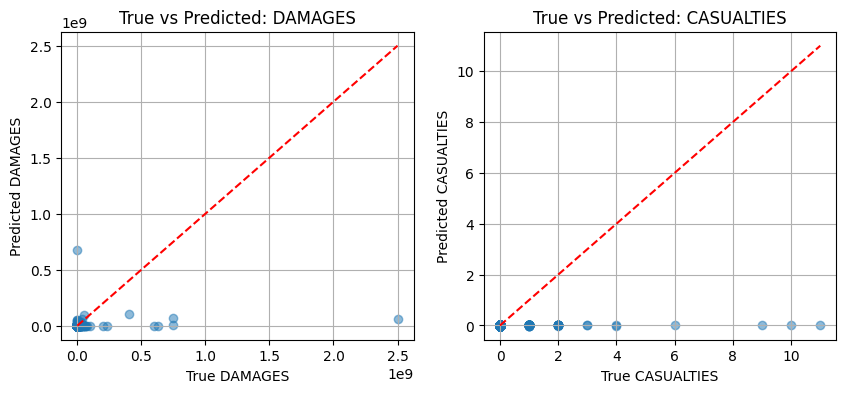

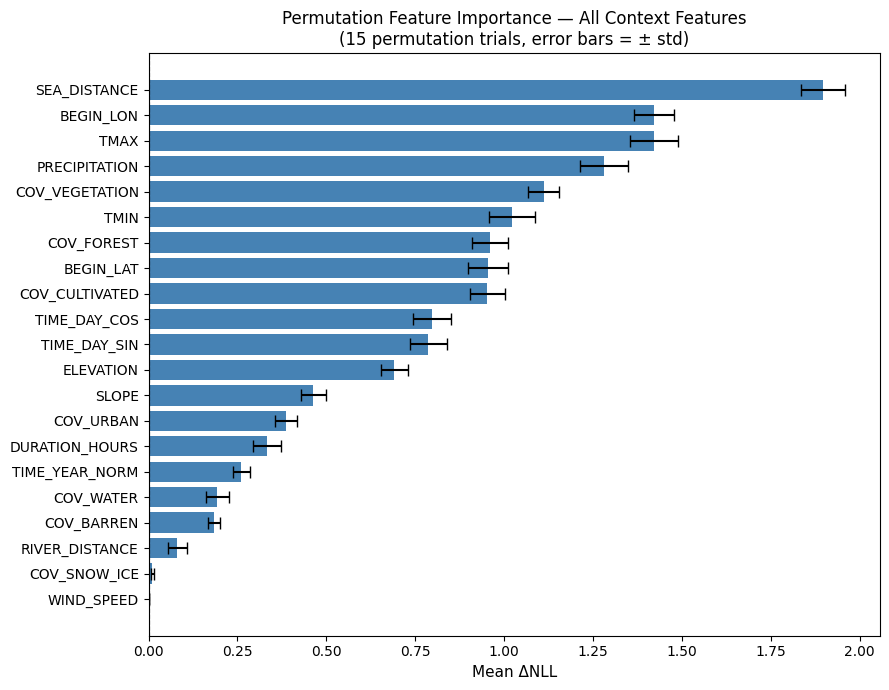

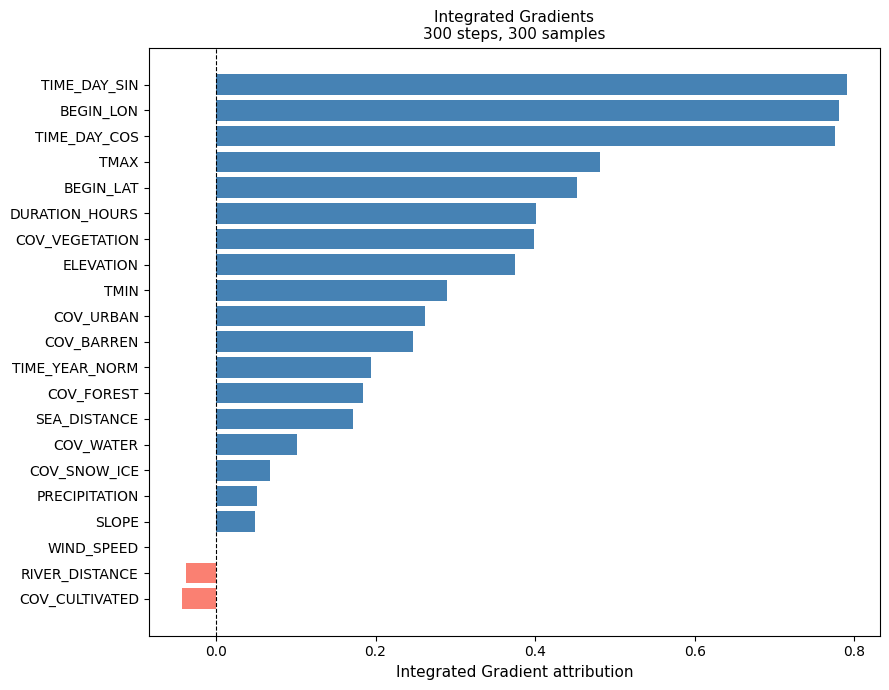

Sum of IGs:      5.9938
Δlog p(y|x):     6.1751
Relative error:  2.9%
(Should be < 5%; if not, increase n_steps for approximate the path integral)


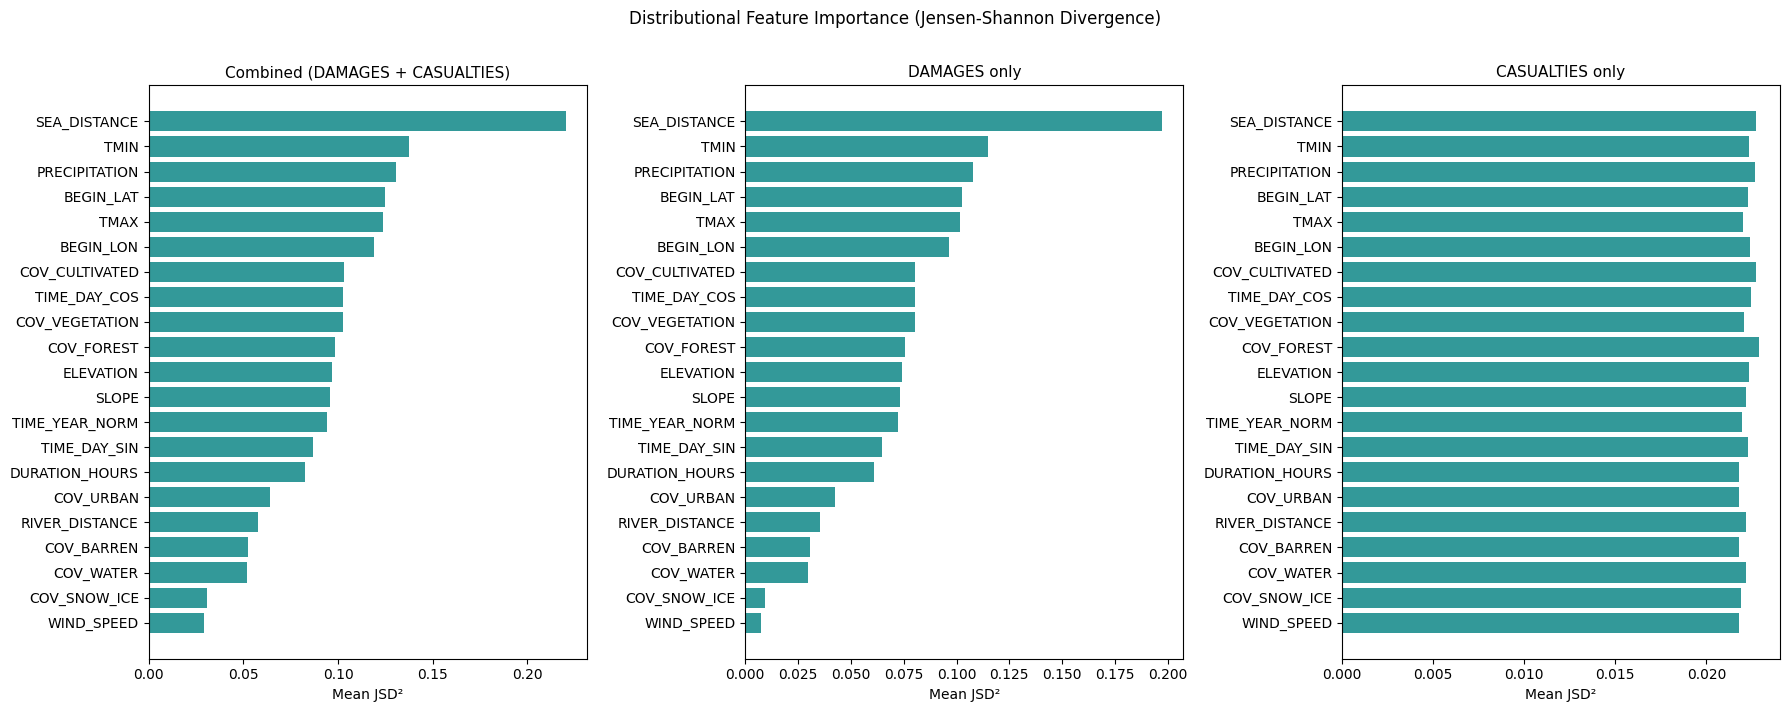

Model moved to cuda
===============FEATURE IMPORTANCE ANALYSIS FOR AVALANCHE MODEL===============


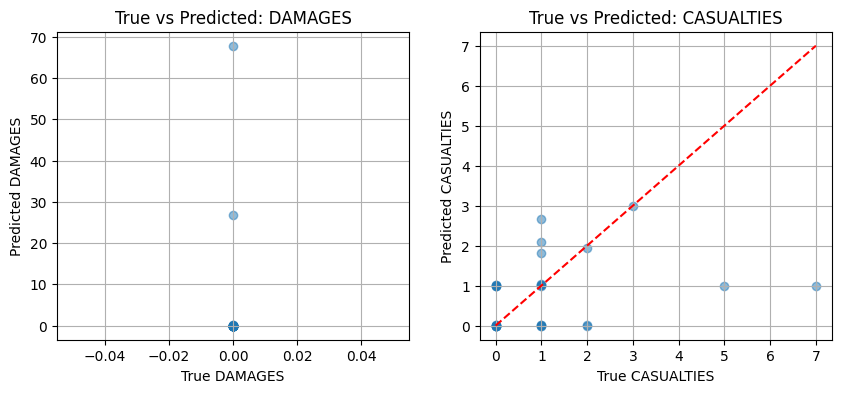

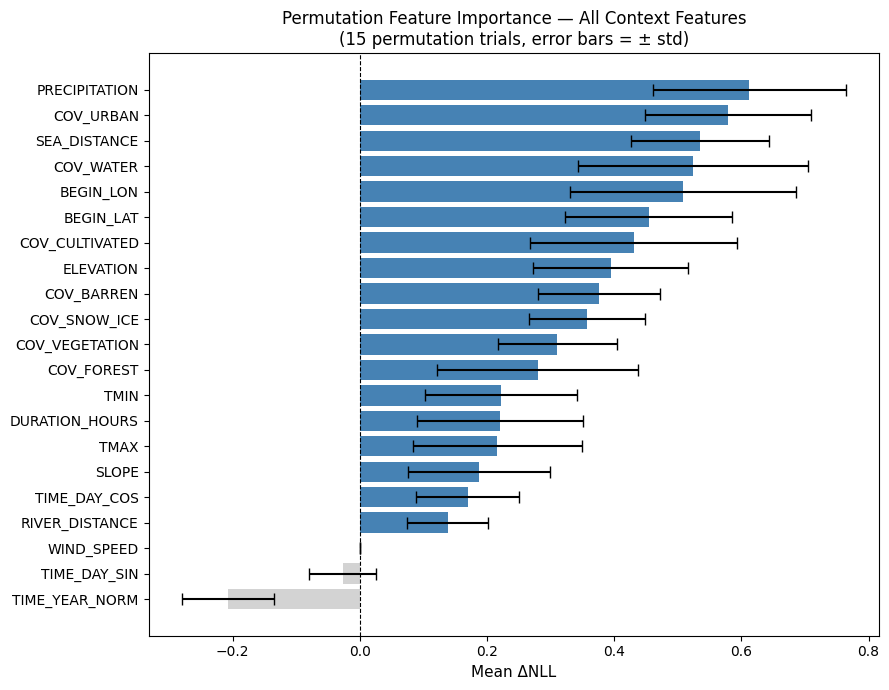

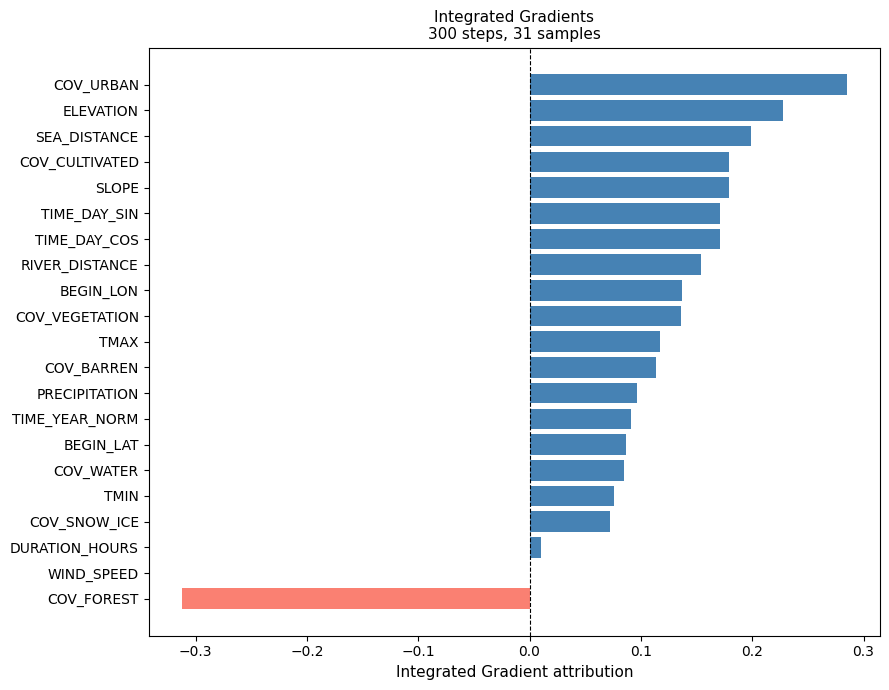

Sum of IGs:      2.2762
Δlog p(y|x):     2.2931
Relative error:  0.7%
(Should be < 5%; if not, increase n_steps for approximate the path integral)


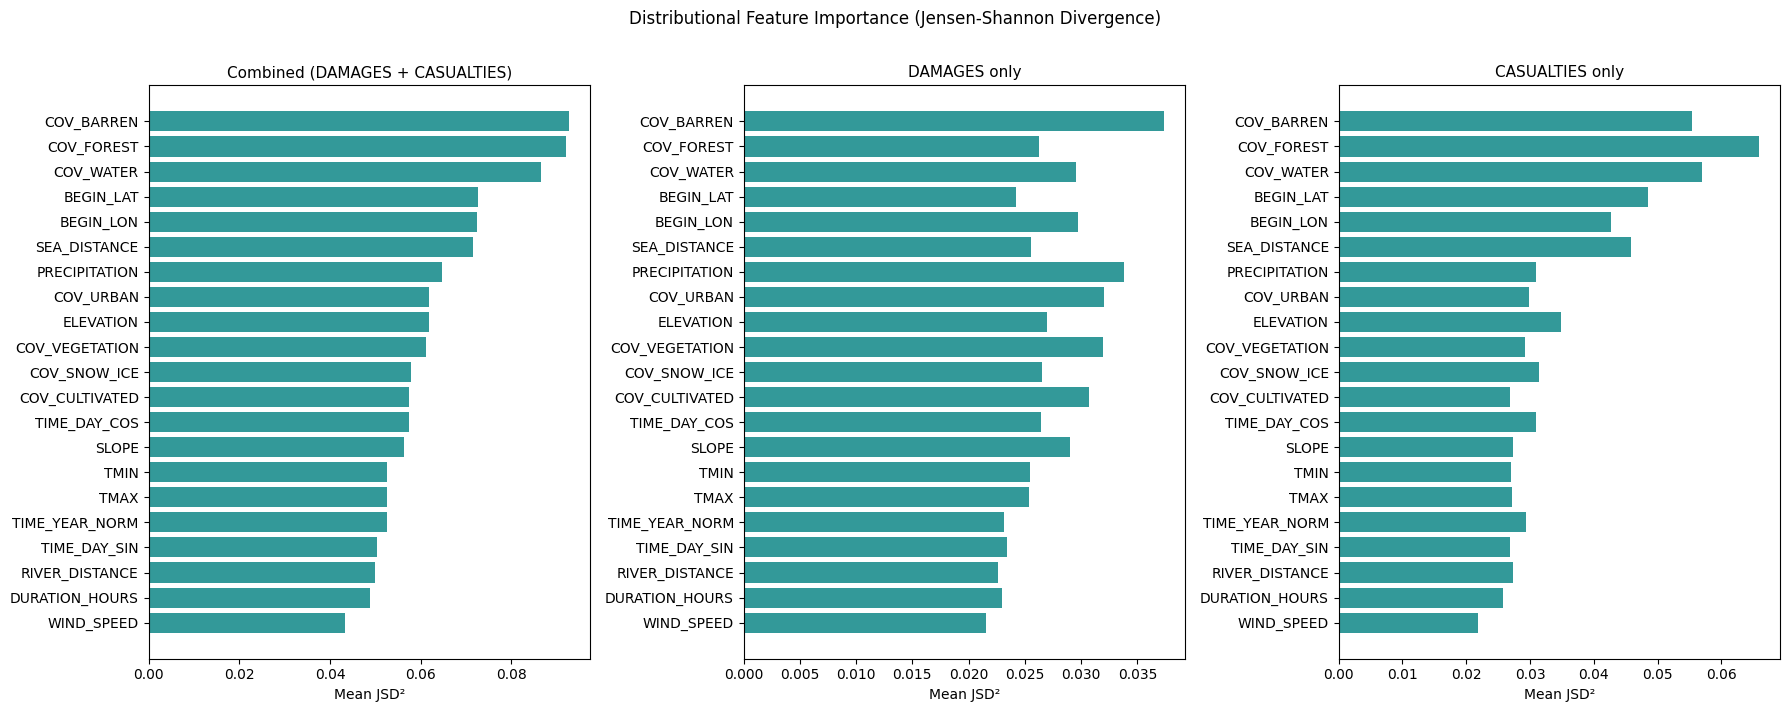

Model moved to cuda
===============FEATURE IMPORTANCE ANALYSIS FOR HEAT MODEL===============


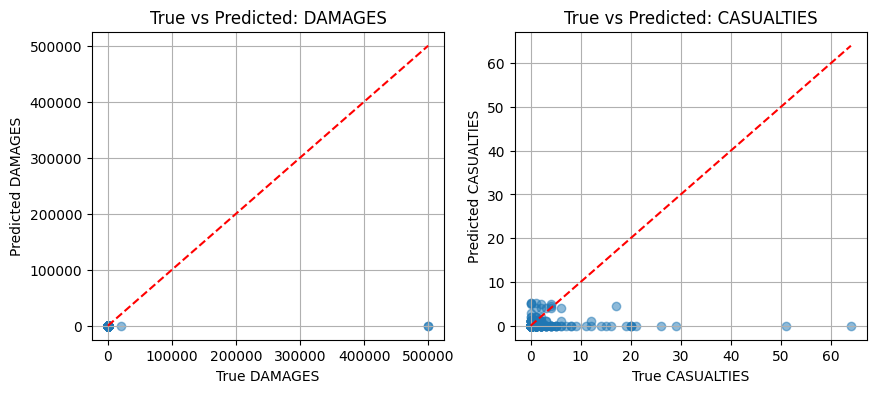

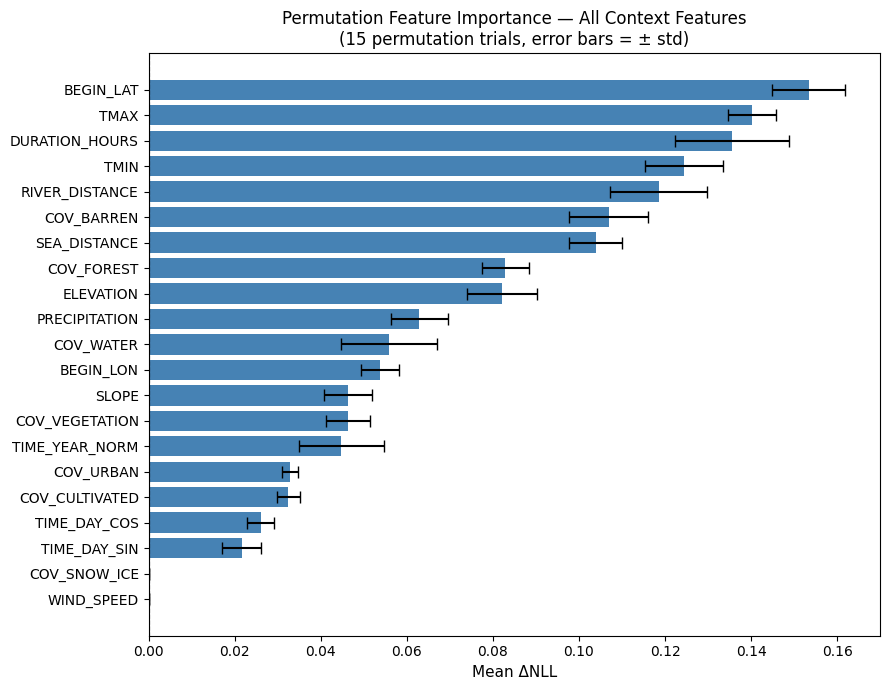

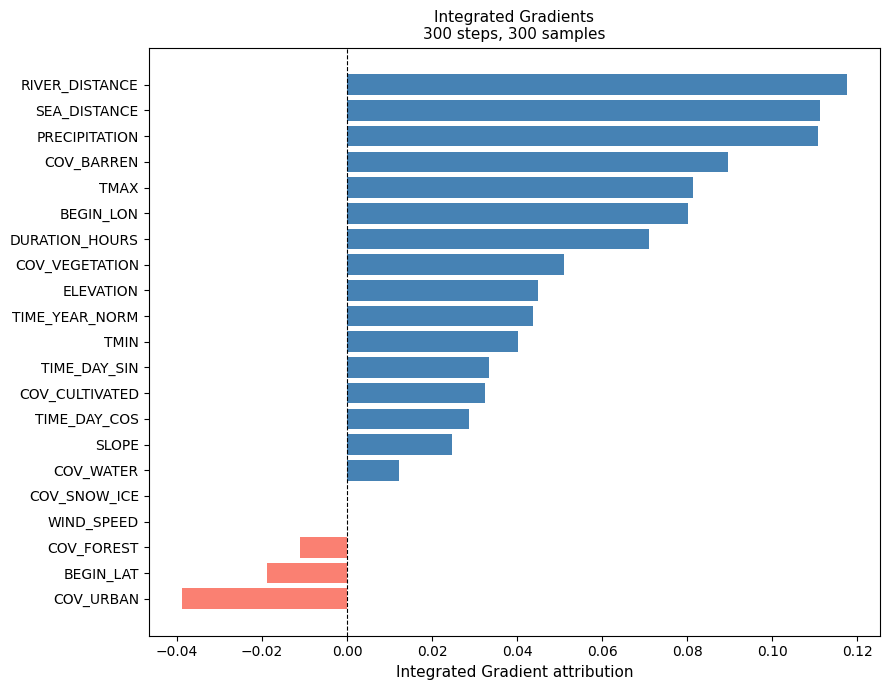

Sum of IGs:      0.9049
Δlog p(y|x):     0.7505
Relative error:  20.6%
(Should be < 5%; if not, increase n_steps for approximate the path integral)


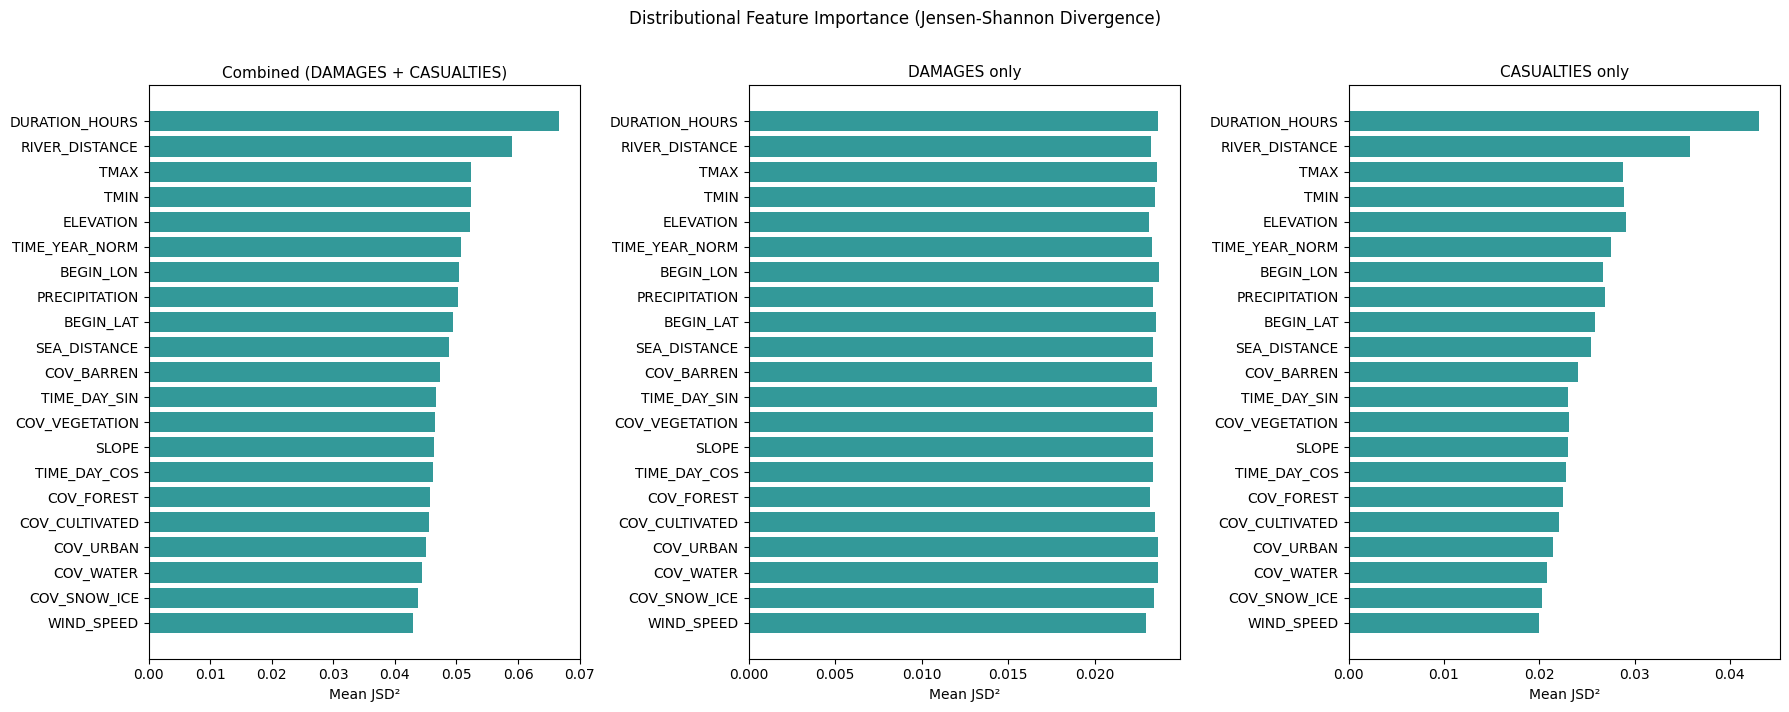

Model moved to cuda
===============FEATURE IMPORTANCE ANALYSIS FOR STORM MODEL===============


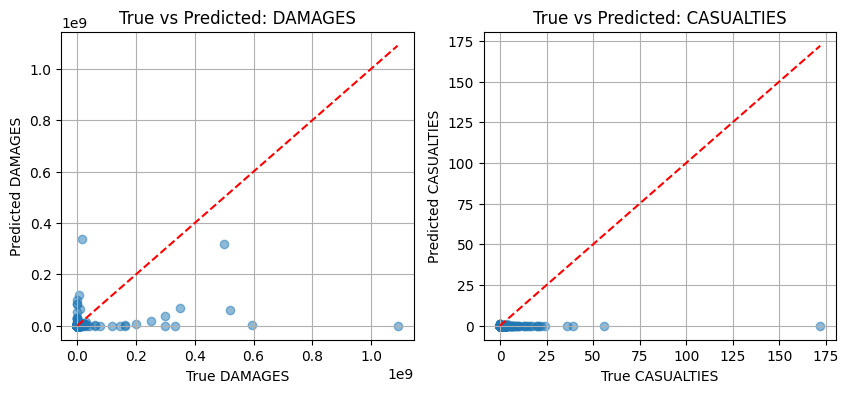

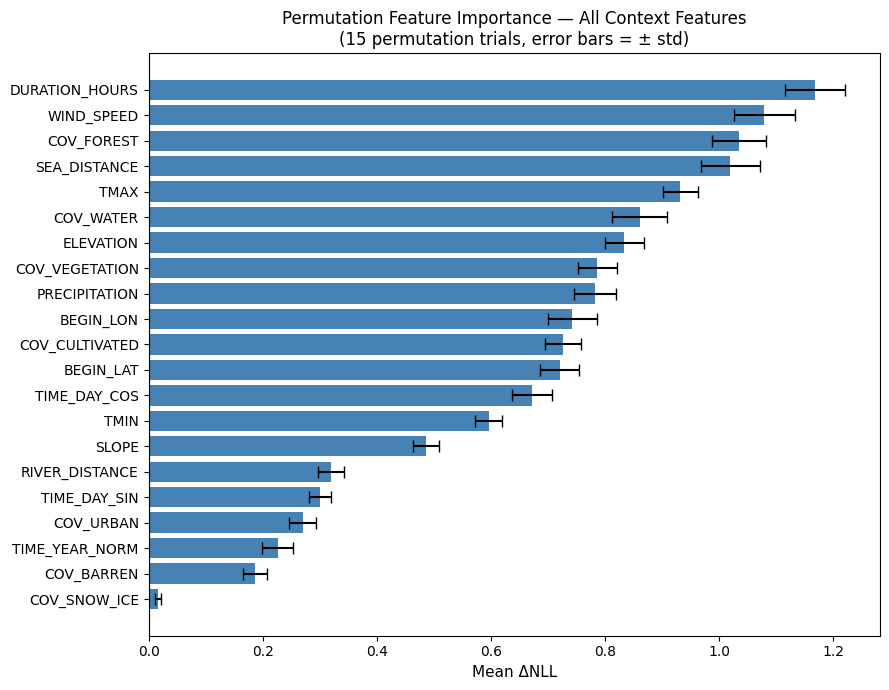

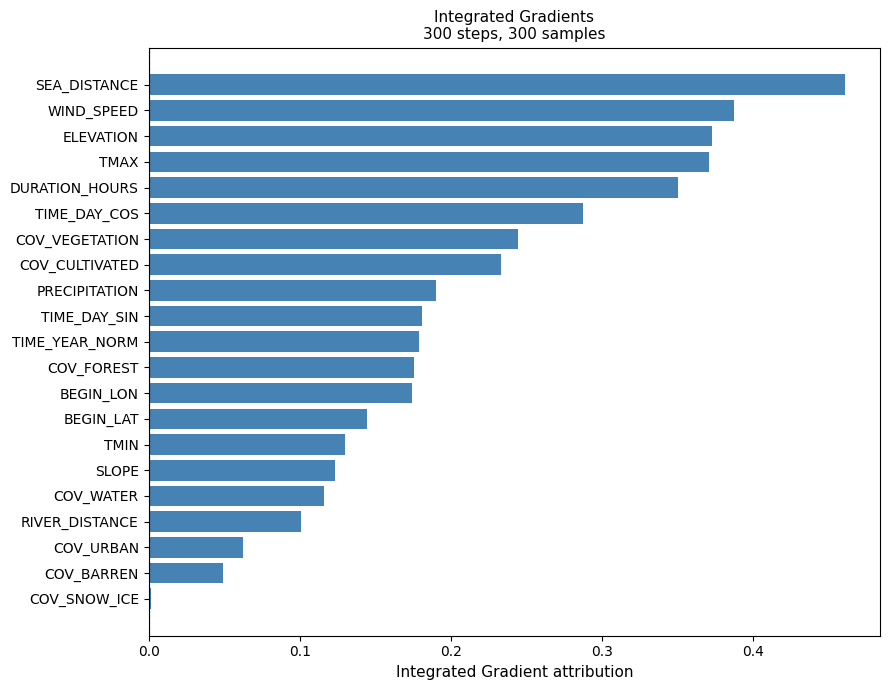

Sum of IGs:      4.3364
Δlog p(y|x):     4.5266
Relative error:  4.2%
(Should be < 5%; if not, increase n_steps for approximate the path integral)


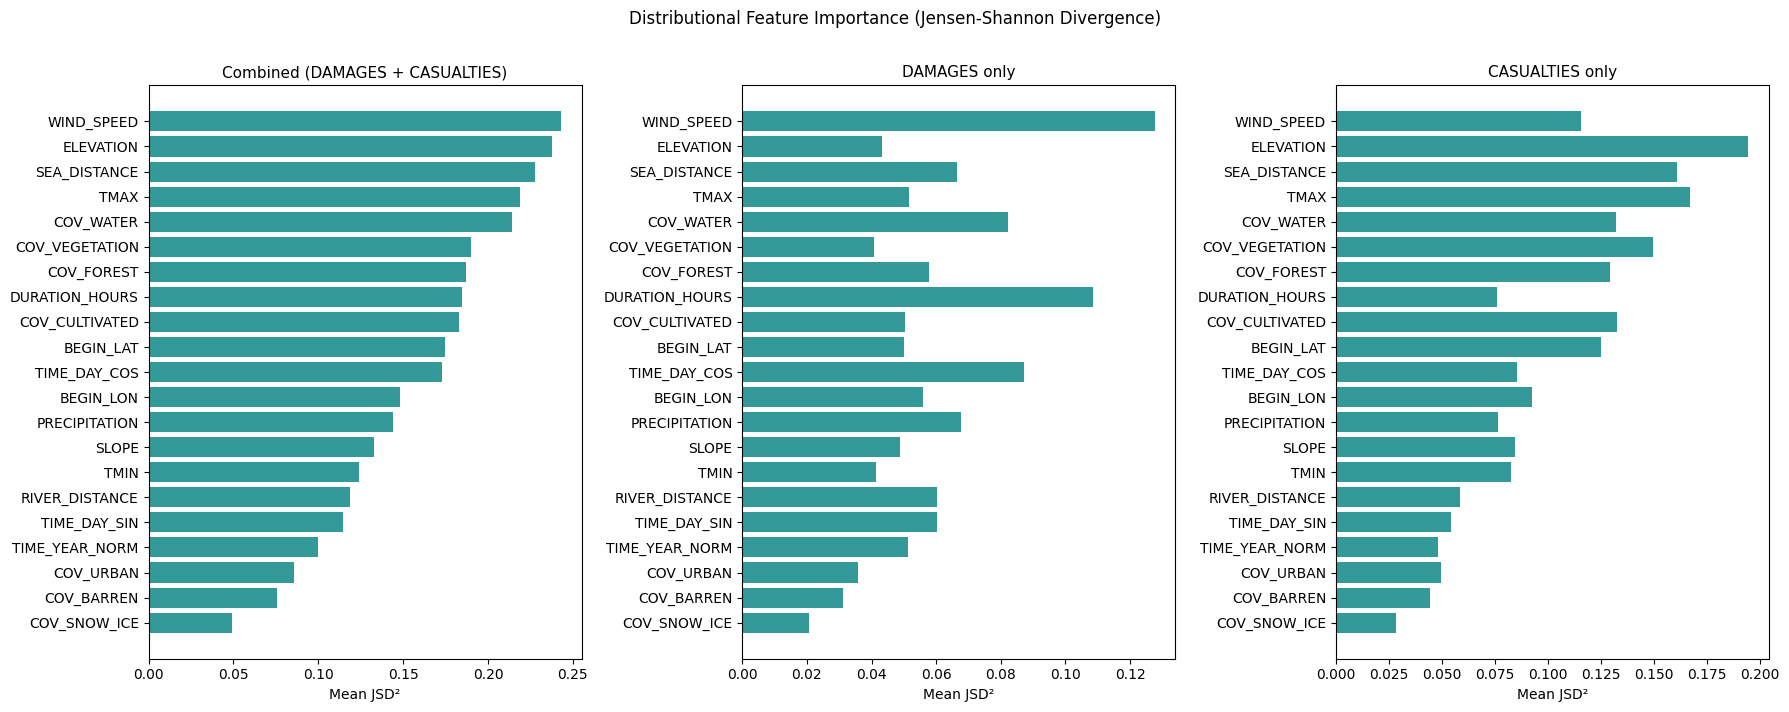

Model moved to cuda
===============FEATURE IMPORTANCE ANALYSIS FOR WILDFIRE MODEL===============


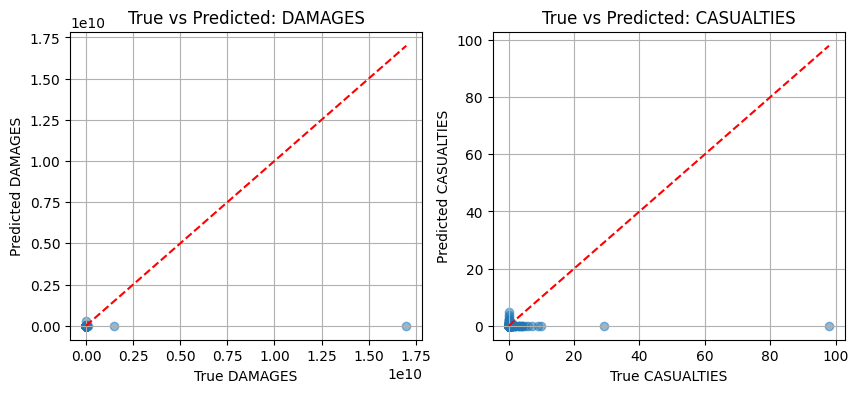

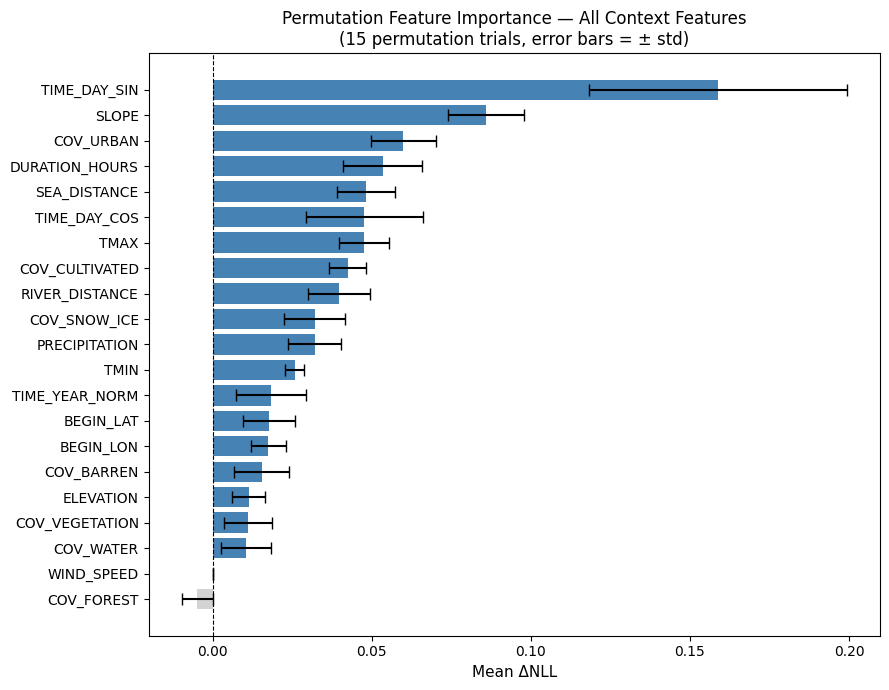

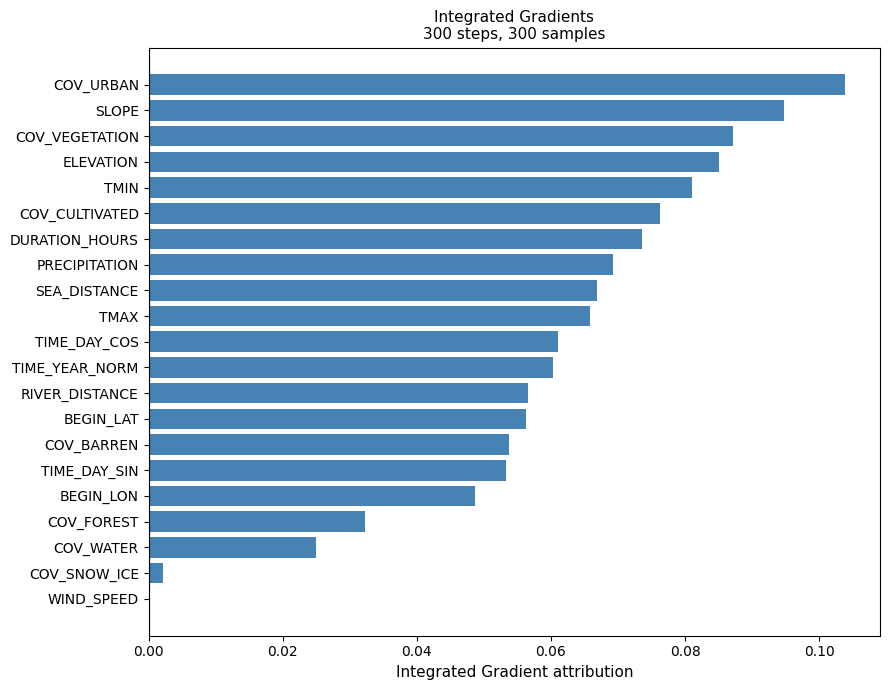

Sum of IGs:      1.2525
Δlog p(y|x):     1.1497
Relative error:  8.9%
(Should be < 5%; if not, increase n_steps for approximate the path integral)


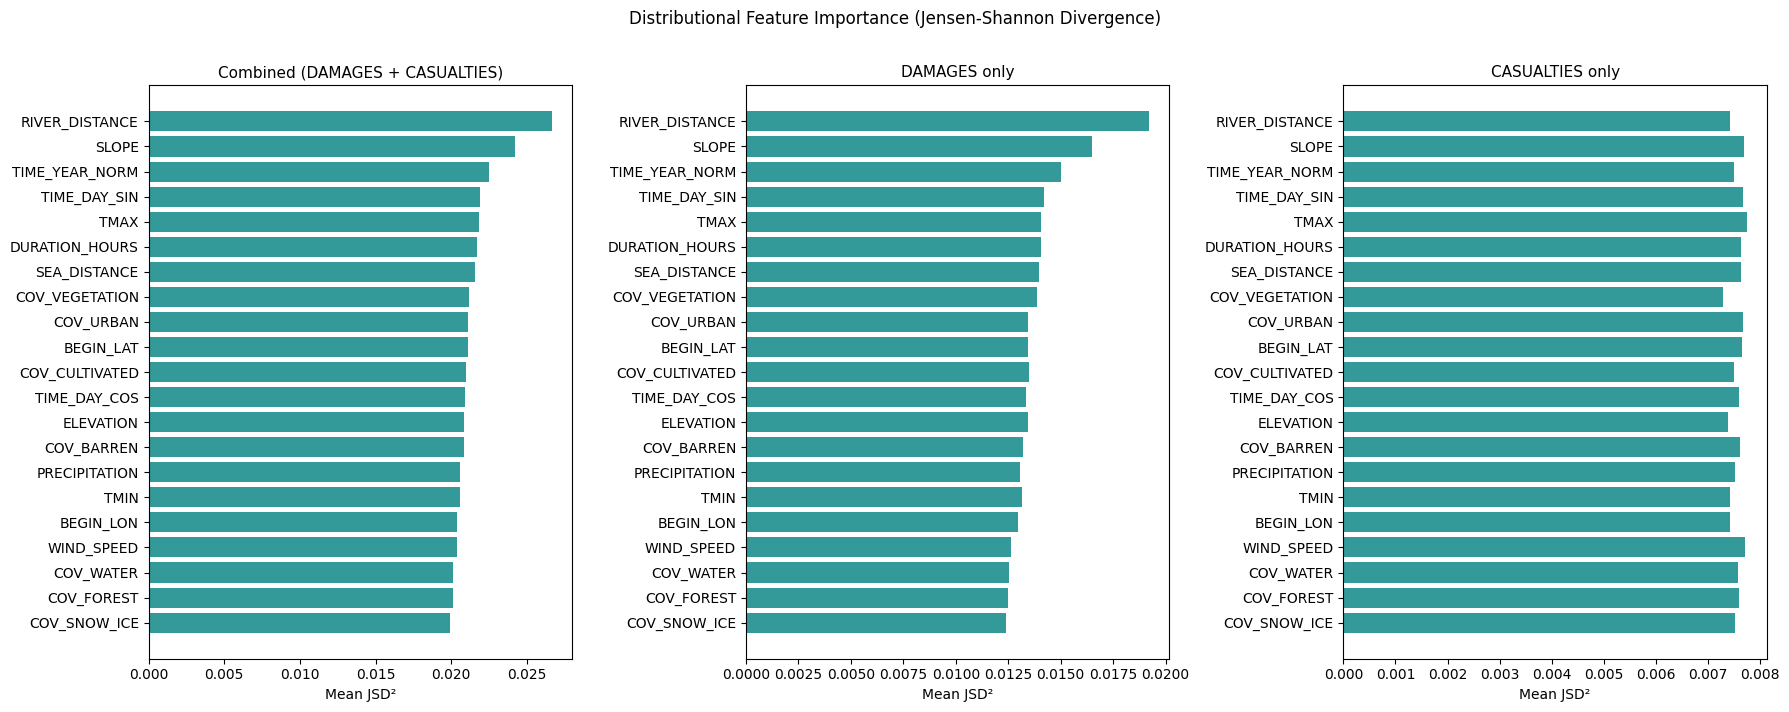

Model moved to cuda
===============FEATURE IMPORTANCE ANALYSIS FOR FREEZE MODEL===============


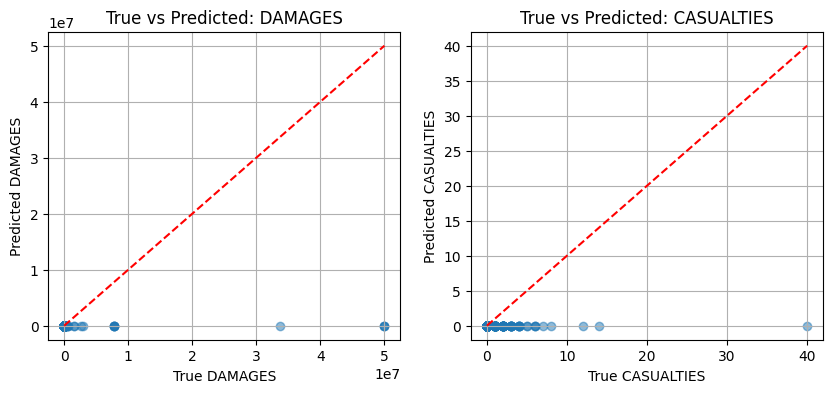

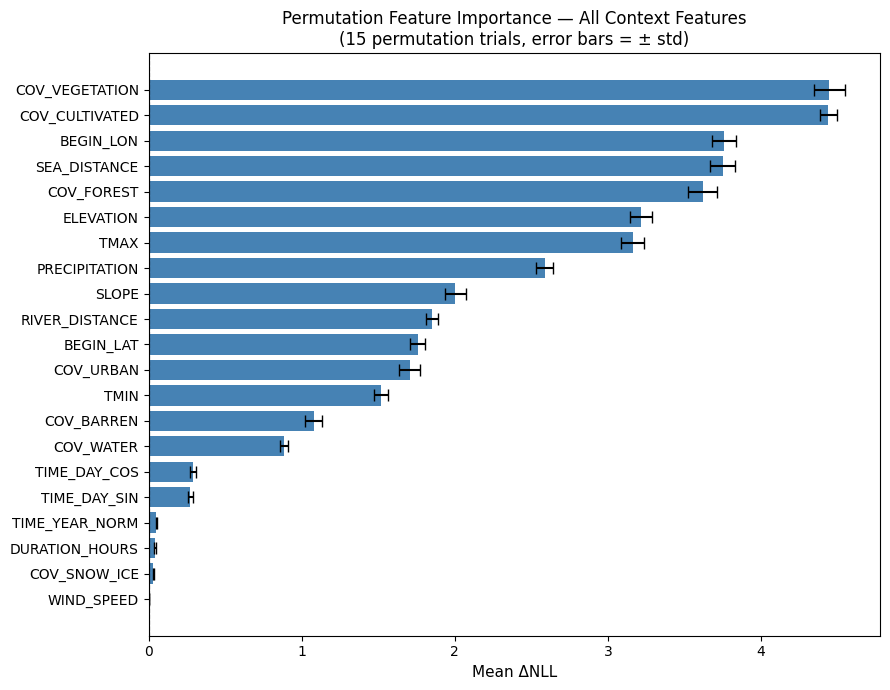

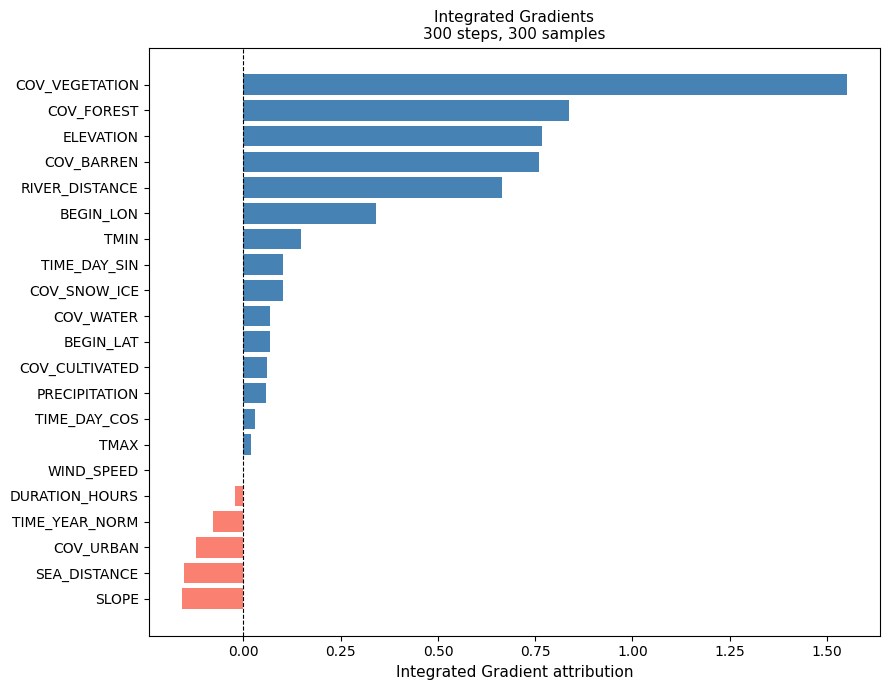

Sum of IGs:      5.0373
Δlog p(y|x):     5.0758
Relative error:  0.8%
(Should be < 5%; if not, increase n_steps for approximate the path integral)


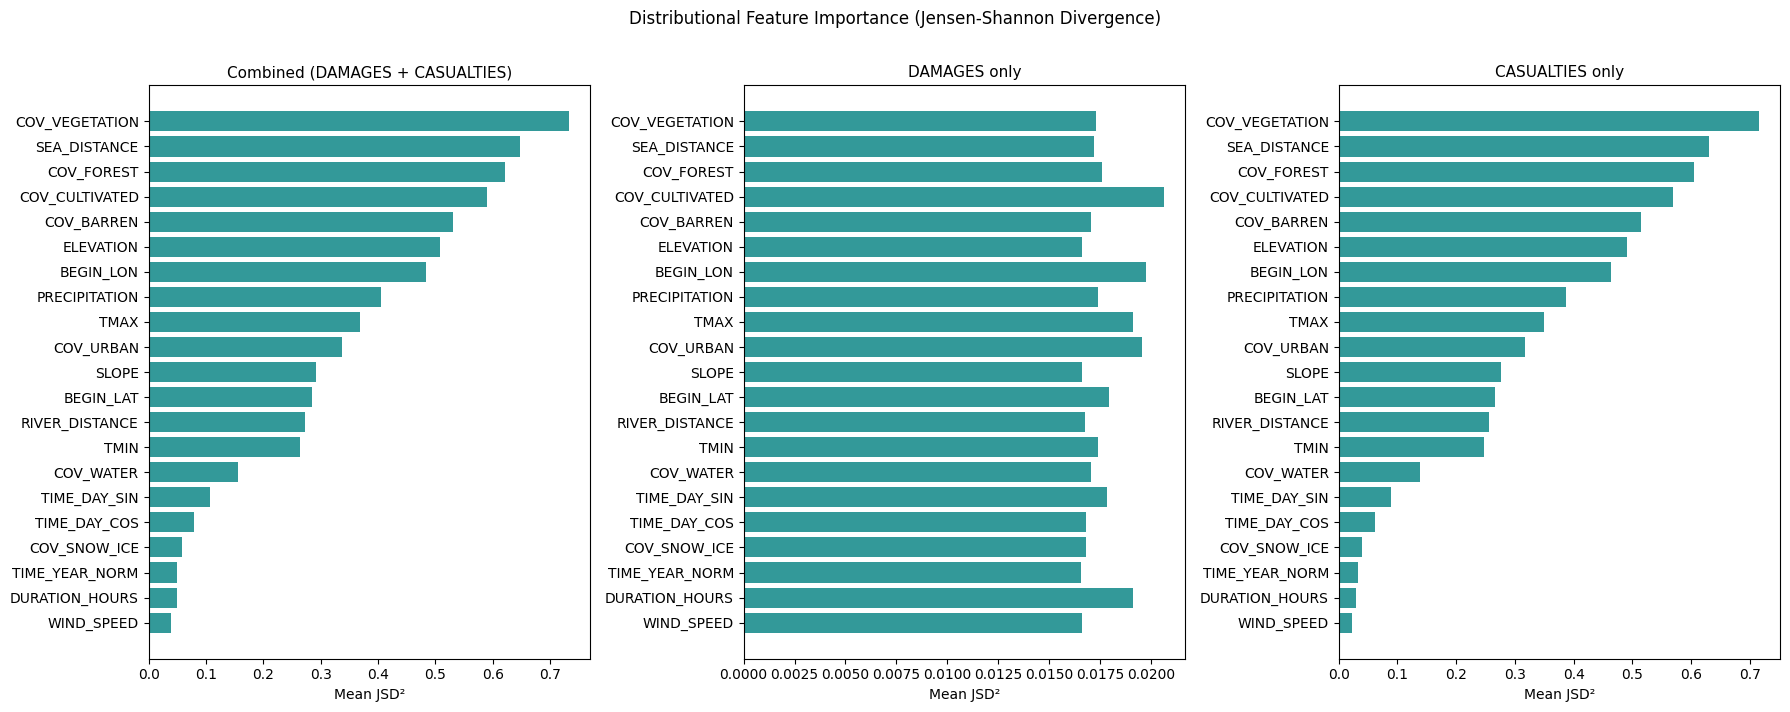

Model moved to cuda
===============FEATURE IMPORTANCE ANALYSIS FOR DROUGHT MODEL===============


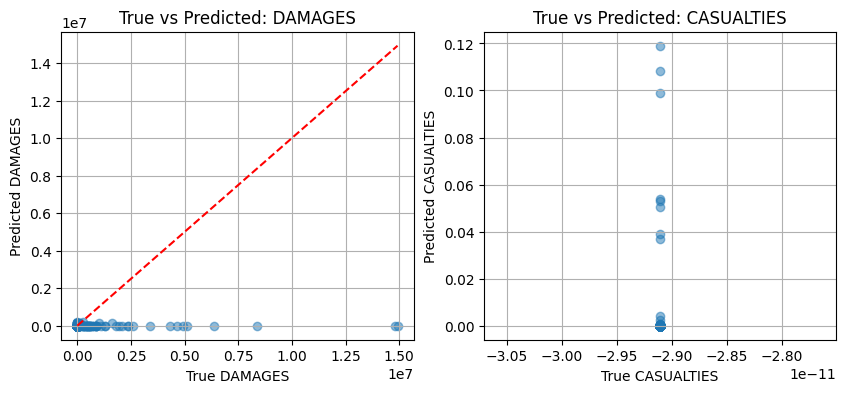

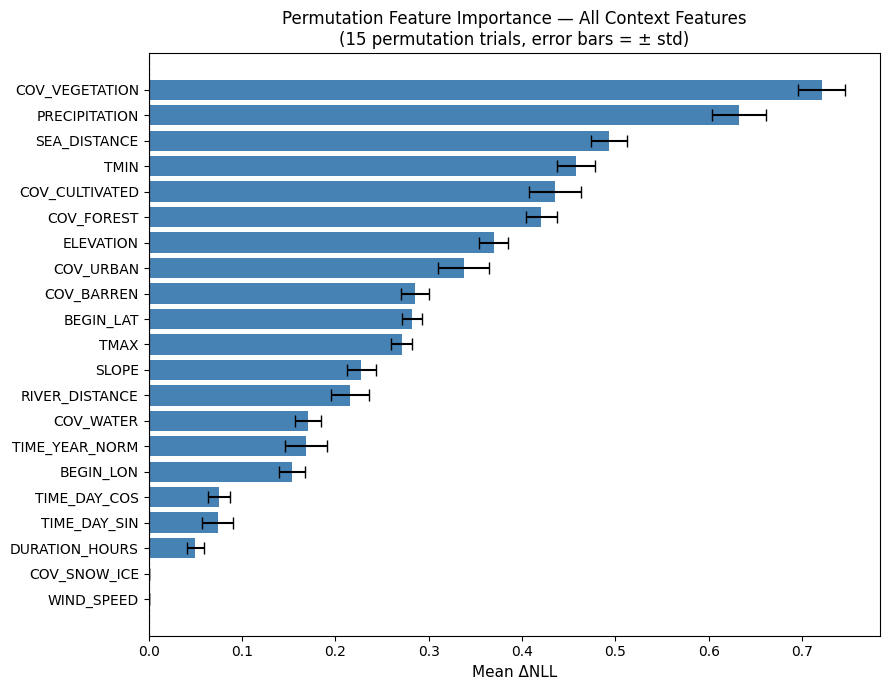

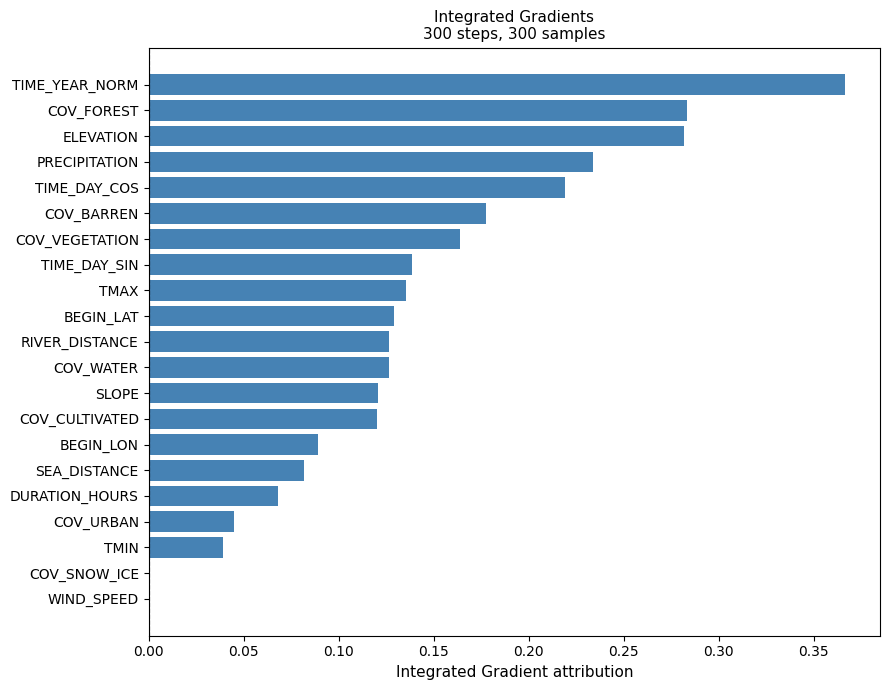

Sum of IGs:      2.9446
Δlog p(y|x):     2.7458
Relative error:  7.2%
(Should be < 5%; if not, increase n_steps for approximate the path integral)


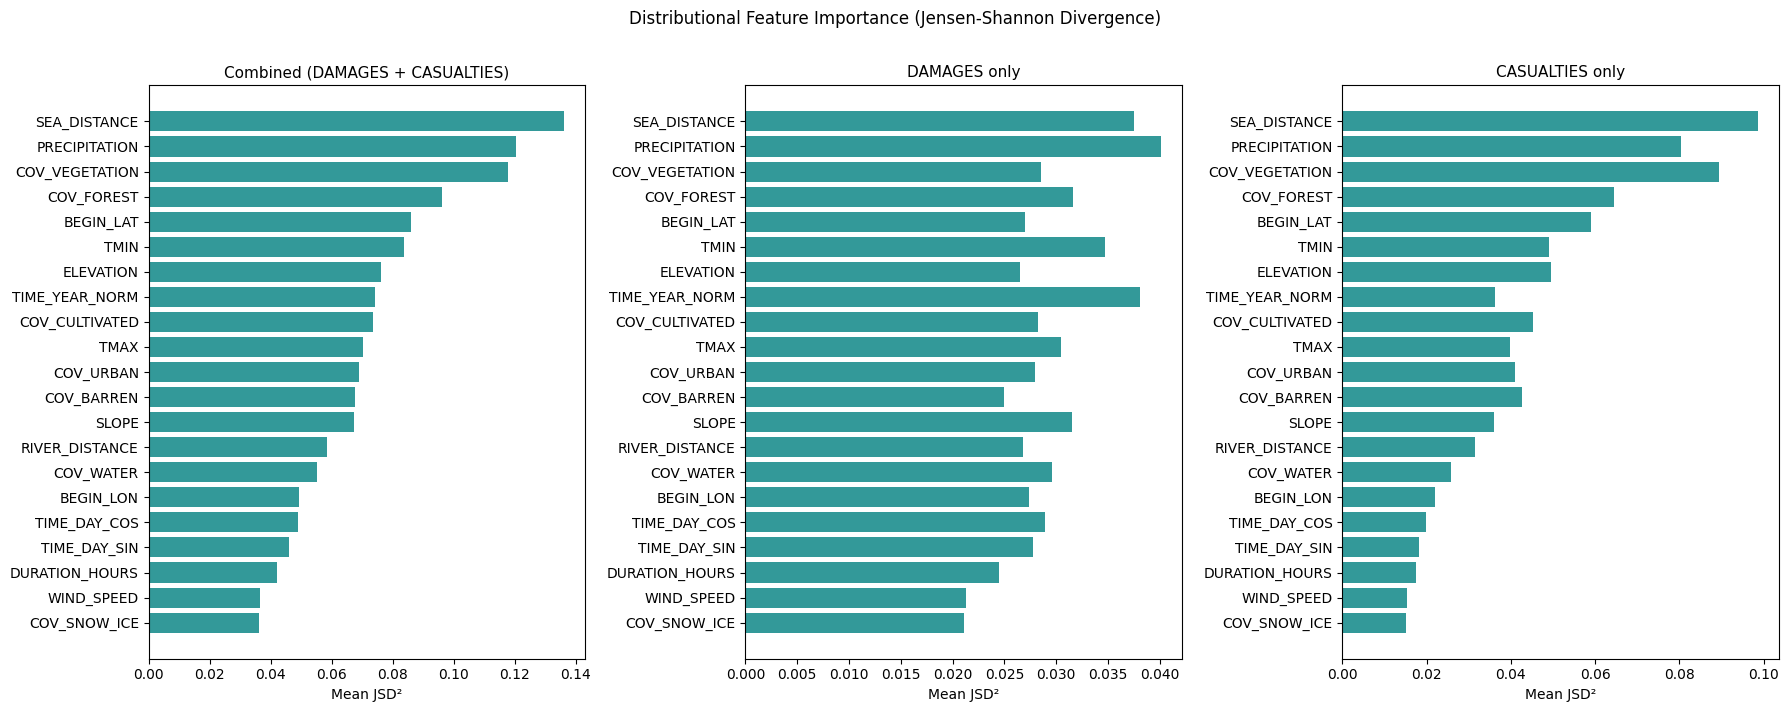

Model moved to cuda
===============FEATURE IMPORTANCE ANALYSIS FOR WIND MODEL===============


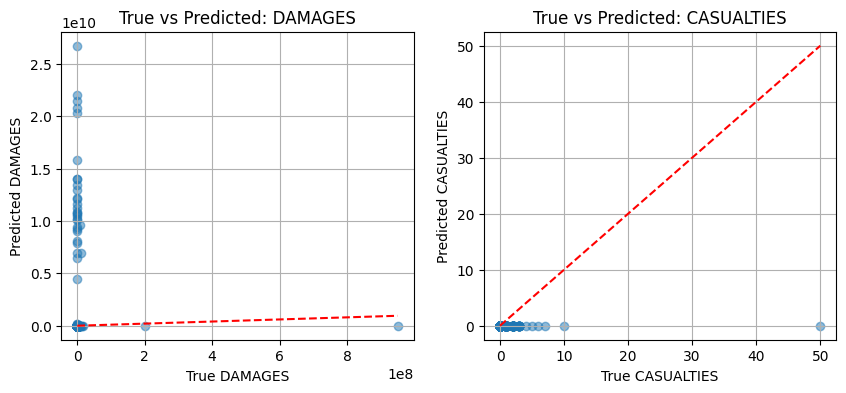

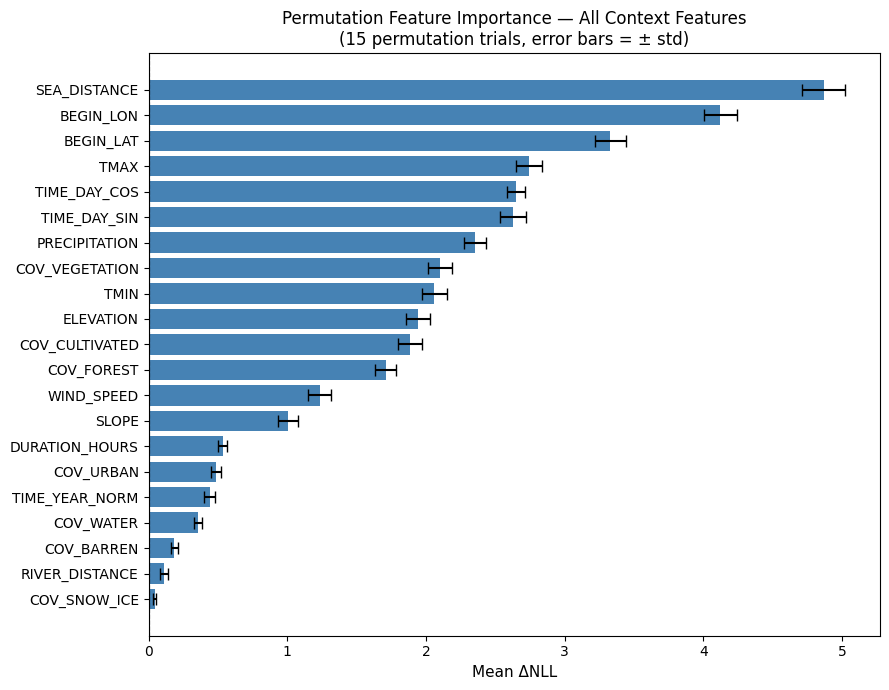

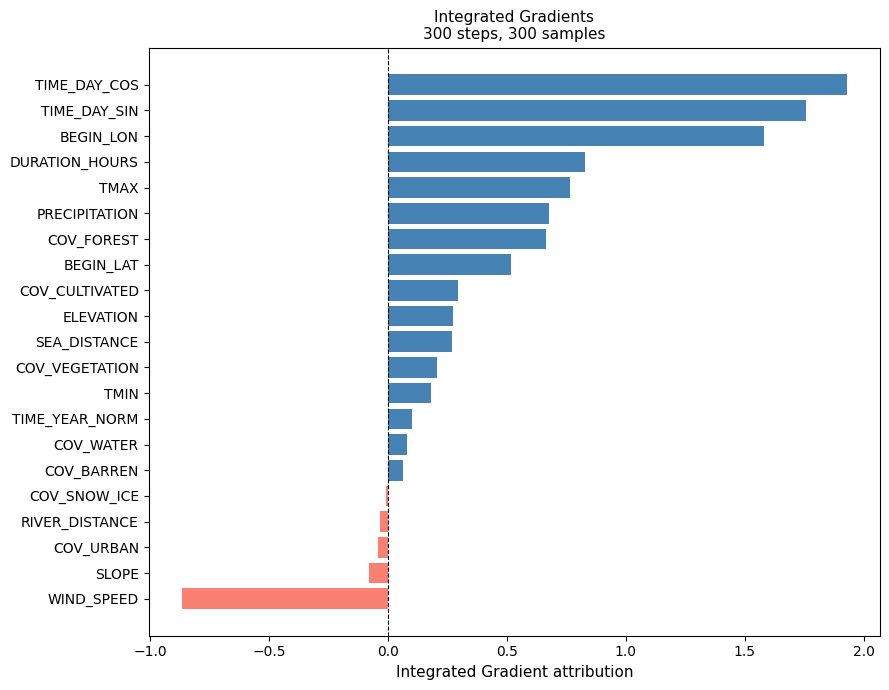

Sum of IGs:      9.1570
Δlog p(y|x):     9.1529
Relative error:  0.0%
(Should be < 5%; if not, increase n_steps for approximate the path integral)


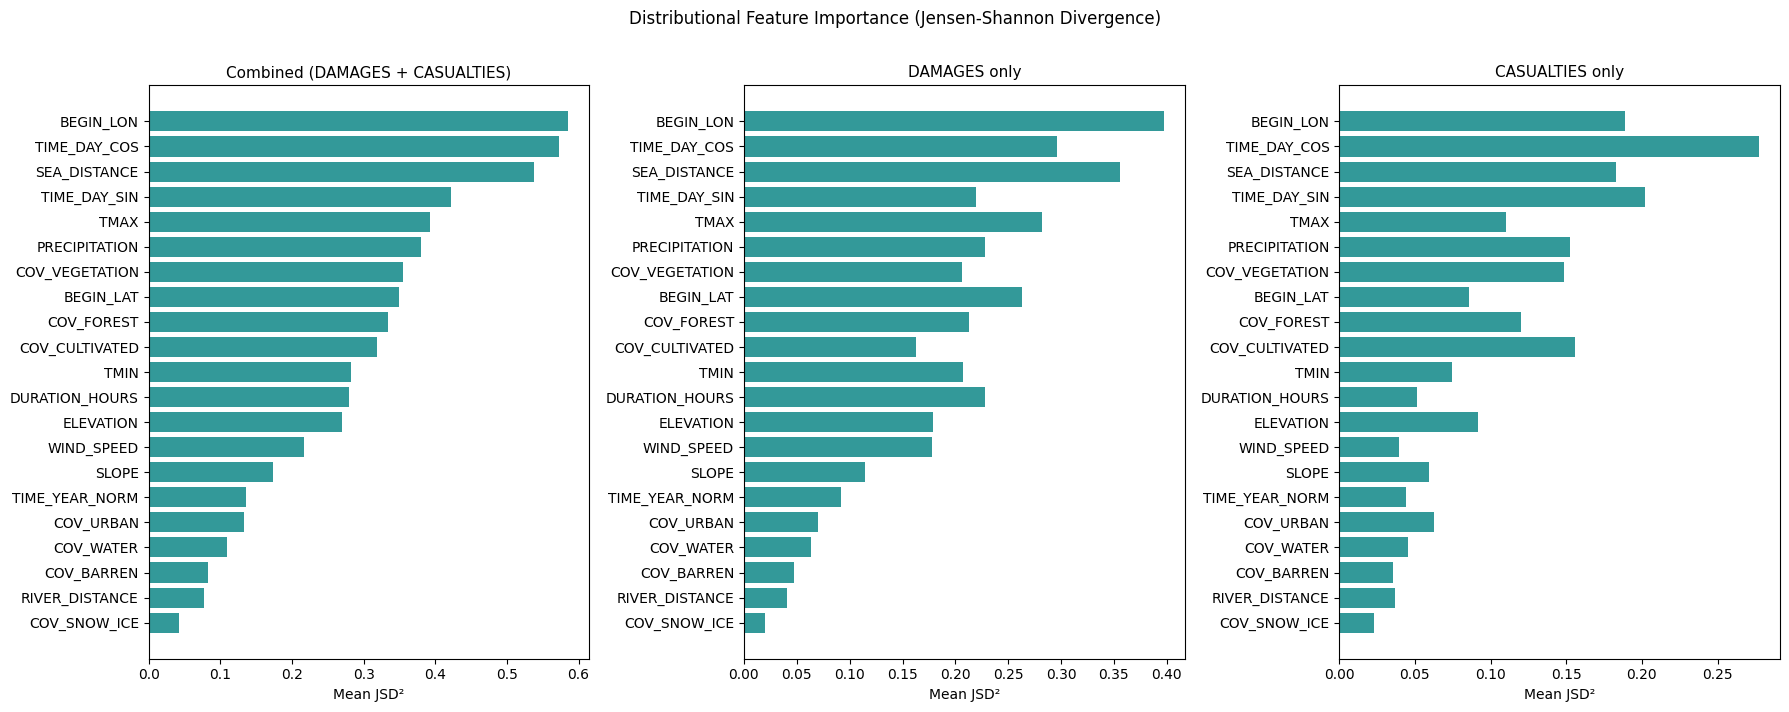

KeyError: 'Heavy_rain'

In [14]:
for e in EVENTS:
    RUN_PATH = Path(f"../runs/best_flow_{e.lower()}.pt")

    df = event_group_dfs[e]

    X = df[X_COLS].values.astype(np.float32)
    Y = df[TARGET_COLS].values.astype(np.float32)

    # targets log transformation
    Y = np.log1p(Y)

    # train-val-test split
    X_train, X_temp, Y_train, Y_temp = train_test_split(X, Y, test_size=0.3, random_state=42)

    X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, random_state=42)

    # standardize features and targets
    x_scaler = StandardScaler()
    y_scaler = StandardScaler()

    X_train = x_scaler.fit_transform(X_train)
    X_val   = x_scaler.transform(X_val)
    X_test  = x_scaler.transform(X_test)

    Y_train = y_scaler.fit_transform(Y_train)
    Y_val   = y_scaler.transform(Y_val)
    Y_test  = y_scaler.transform(Y_test)

    # conversion to tensors
    X_train = torch.tensor(X_train)
    Y_train = torch.tensor(Y_train)

    X_val = torch.tensor(X_val)
    Y_val = torch.tensor(Y_val)

    X_test = torch.tensor(X_test)
    Y_test = torch.tensor(Y_test)

    # data loaders
    train_ds = TensorDataset(X_train, Y_train)
    val_ds   = TensorDataset(X_val, Y_val)
    test_ds   = TensorDataset(X_val, Y_val)
    test_loader= DataLoader(test_ds, batch_size=BATCH_SIZE)

    # Load model weights
    flow.load_state_dict(torch.load(RUN_PATH, weights_only=True))
    flow.eval()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    flow = flow.to(device)
    print(f"Model moved to {device}")
    
    print(f"{'='*15}FEATURE IMPORTANCE ANALYSIS FOR {e.upper()} MODEL{'='*15}")

    # Print prediction vs ground truth
    utils.run_inference_and_plot(flow, test_loader, y_scaler, TARGET_COLS, device)

    # ====== FEATURE IMPORTANCE ANALYSIS ======
    
    _, _ = permutation_importance_full(flow, X_test, Y_test, X_COLS, device)
    
    ig_scores = integrated_gradients(flow, X_test, Y_test, X_COLS, device)
    verify_ig_completeness(flow, X_test, Y_test, ig_scores, device)

    _, _, _ = distributional_importance(flow, X_test, X_COLS, device)


    

# Flood

Model moved to cuda


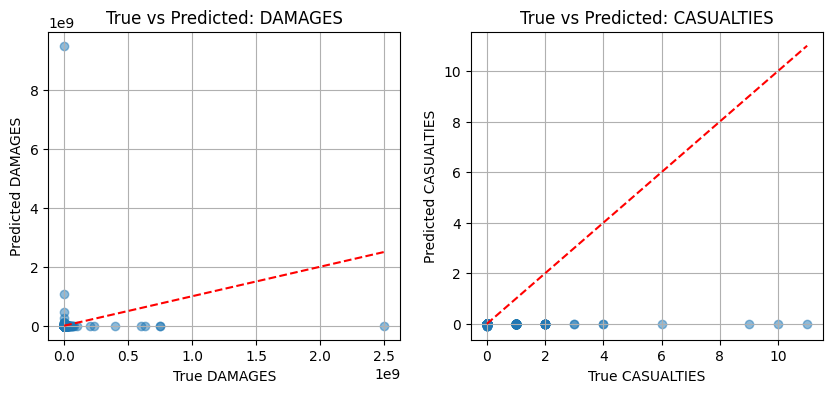

In [ ]:
EVENT_GROUP = 'Flood'
RUN_PATH = Path(f"../runs/flow_{EVENT_GROUP.lower()}.pt")

df = event_group_dfs[EVENT_GROUP]

X = df[X_COLS].values.astype(np.float32)
Y = df[TARGET_COLS].values.astype(np.float32)

# targets log transformation
Y = np.log1p(Y)

# train-val-test split
X_train, X_temp, Y_train, Y_temp = train_test_split(X, Y, test_size=0.3, random_state=42)

X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, random_state=42)

# standardize features and targets
x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train = x_scaler.fit_transform(X_train)
X_val   = x_scaler.transform(X_val)
X_test  = x_scaler.transform(X_test)

Y_train = y_scaler.fit_transform(Y_train)
Y_val   = y_scaler.transform(Y_val)
Y_test  = y_scaler.transform(Y_test)

# conversion to tensors
X_train = torch.tensor(X_train)
Y_train = torch.tensor(Y_train)

X_val = torch.tensor(X_val)
Y_val = torch.tensor(Y_val)

X_test = torch.tensor(X_test)
Y_test = torch.tensor(Y_test)

# data loaders
train_ds = TensorDataset(X_train, Y_train)
val_ds   = TensorDataset(X_val, Y_val)
test_ds   = TensorDataset(X_val, Y_val)
test_loader= DataLoader(test_ds, batch_size=BATCH_SIZE)

# Load model weights
flow.load_state_dict(torch.load(RUN_PATH, weights_only=True))
flow.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
flow = flow.to(device)
print(f"Model moved to {device}")

# Print prediction vs ground truth
utils.run_inference_and_plot(flow, test_loader, y_scaler, TARGET_COLS, device)

## Feature importance analysis

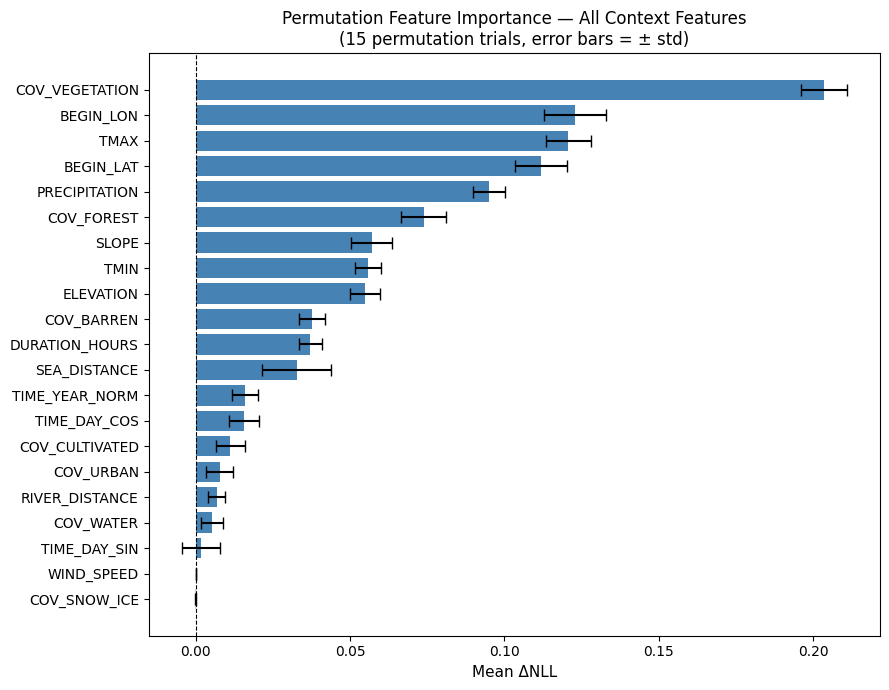

In [ ]:
flood_means, flood_stds = permutation_importance_full(flow, X_test, Y_test, X_COLS, device)

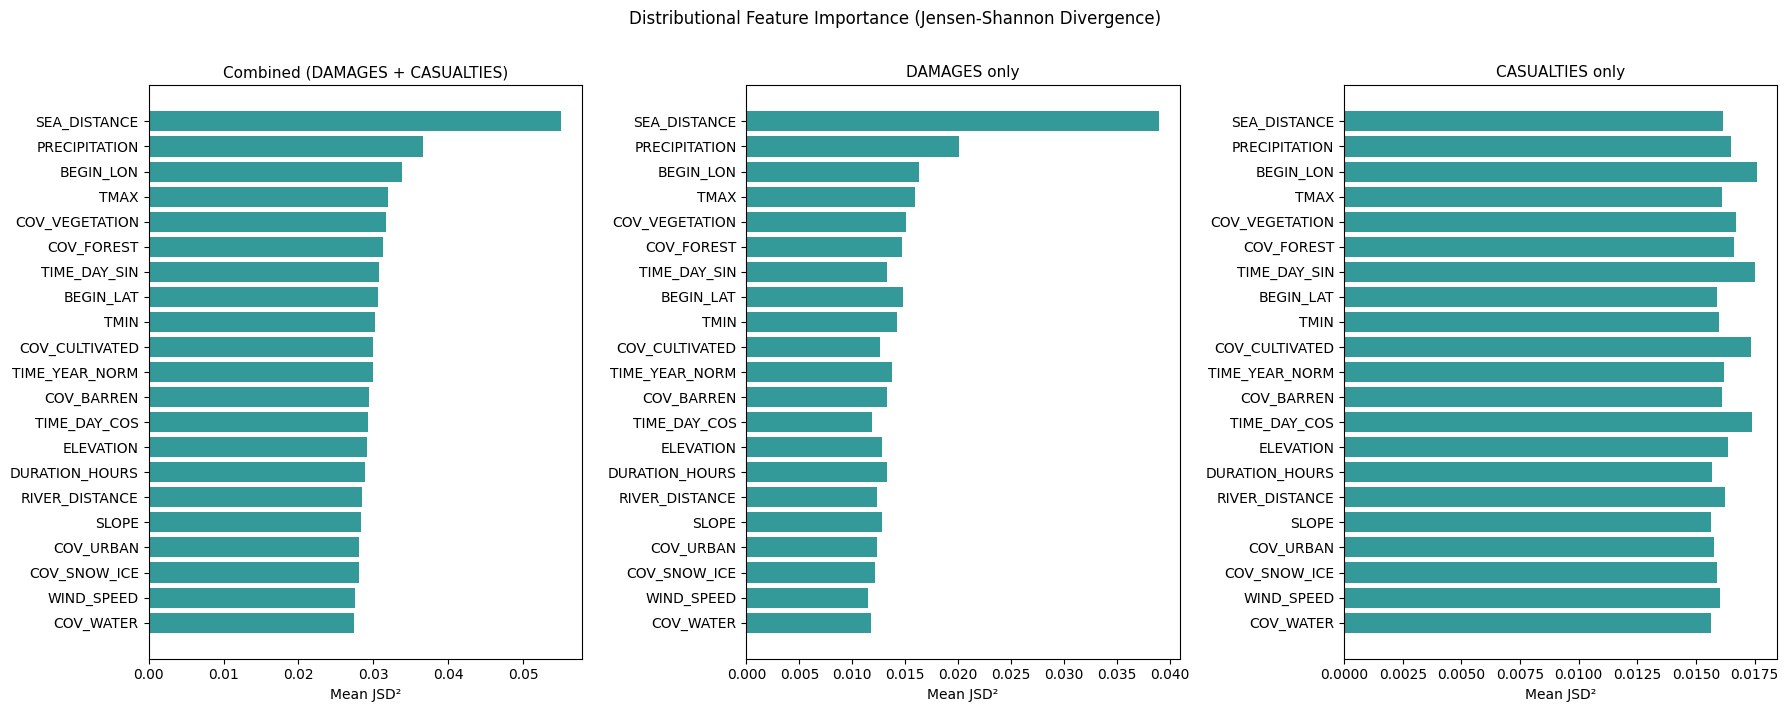

In [ ]:
flood_JSD_targets, flood_JSD_damages, flood_JSD_casualities = distributional_importance(flow, X_test, X_COLS, device)

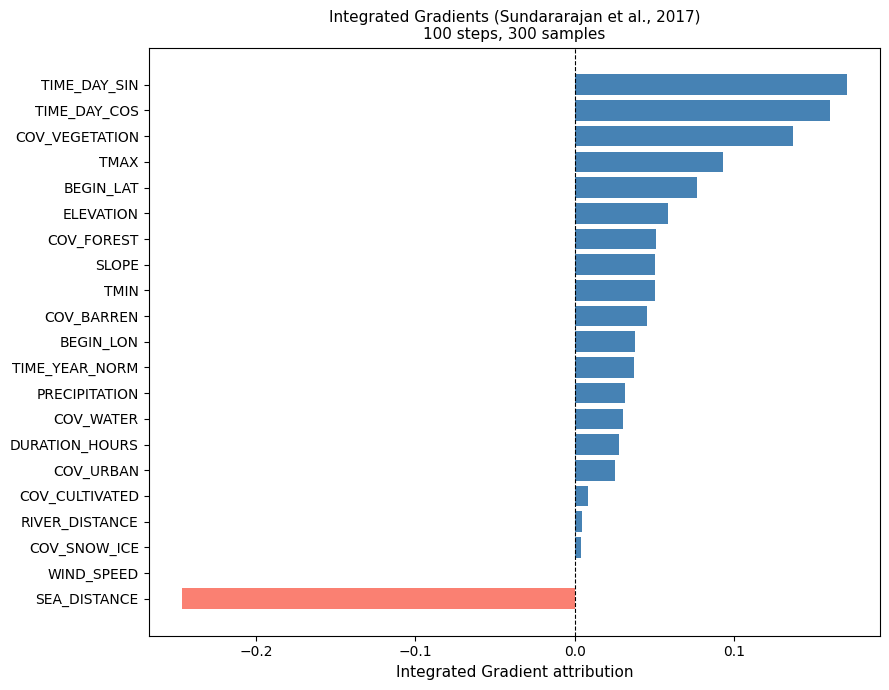

In [ ]:
IG_flood = integrated_gradients(flow, X_test, Y_test, X_COLS, device)

In [ ]:
IG_flood_scipy = integrated_gradients_scipy(flow, X_test, Y_test, X_COLS, device)

RuntimeError: grad can be implicitly created only for scalar outputs

# Storm

Model moved to cuda


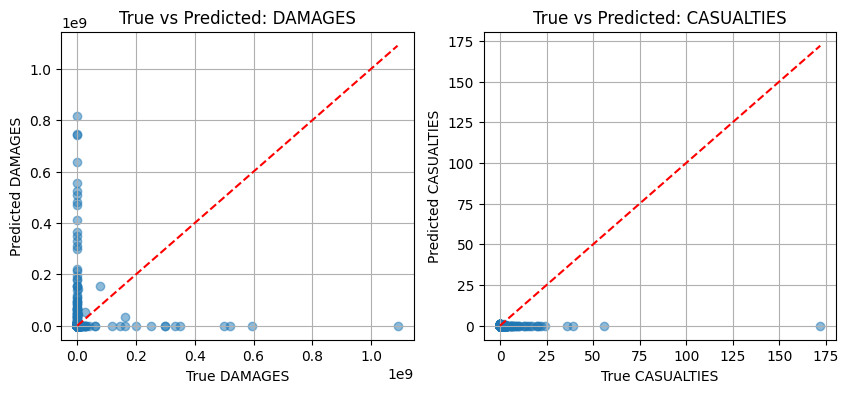

In [ ]:
EVENT_GROUP = 'Storm'
RUN_PATH = Path(f"../runs/flow_{EVENT_GROUP.lower()}.pt")

df = event_group_dfs[EVENT_GROUP]

X = df[X_COLS].values.astype(np.float32)
Y = df[TARGET_COLS].values.astype(np.float32)

# targets log transformation
Y = np.log1p(Y)

# train-val-test split
X_train, X_temp, Y_train, Y_temp = train_test_split(X, Y, test_size=0.3, random_state=42)

X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, random_state=42)

# standardize features and targets
x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train = x_scaler.fit_transform(X_train)
X_val   = x_scaler.transform(X_val)
X_test  = x_scaler.transform(X_test)

Y_train = y_scaler.fit_transform(Y_train)
Y_val   = y_scaler.transform(Y_val)
Y_test  = y_scaler.transform(Y_test)

# conversion to tensors
X_train = torch.tensor(X_train)
Y_train = torch.tensor(Y_train)

X_val = torch.tensor(X_val)
Y_val = torch.tensor(Y_val)

X_test = torch.tensor(X_test)
Y_test = torch.tensor(Y_test)

# data loaders
train_ds = TensorDataset(X_train, Y_train)
val_ds   = TensorDataset(X_val, Y_val)
test_ds   = TensorDataset(X_val, Y_val)
test_loader= DataLoader(test_ds, batch_size=BATCH_SIZE)

# Load model weights
flow.load_state_dict(torch.load(RUN_PATH, weights_only=True))
flow.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
flow = flow.to(device)
print(f"Model moved to {device}")

# Print prediction vs ground truth
utils.run_inference_and_plot(flow, test_loader, y_scaler, TARGET_COLS, device)

## Feature importance analysis

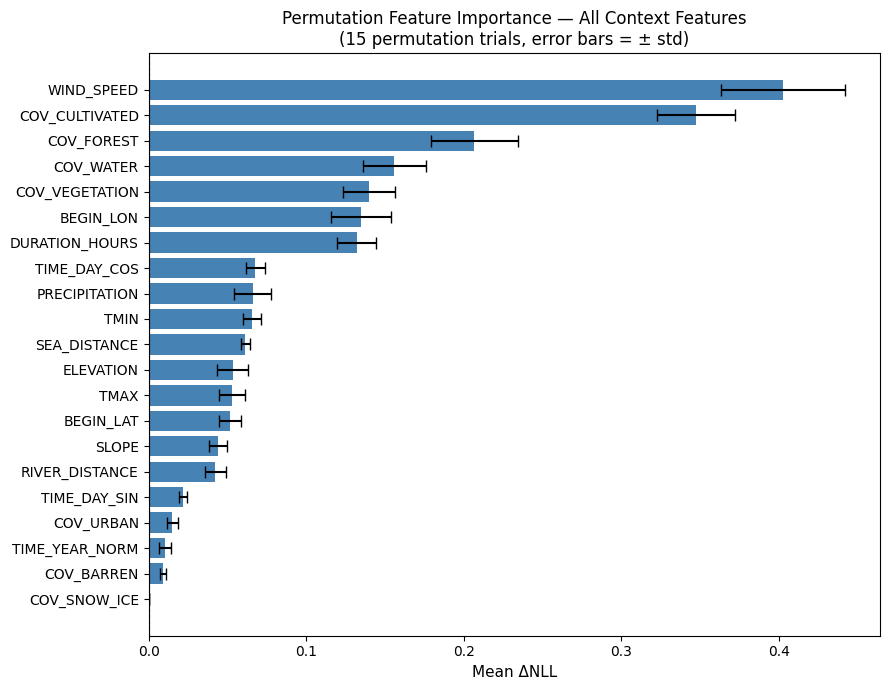

In [ ]:
storm_means, storm_stds = permutation_importance_full(flow, X_test, Y_test, X_COLS, device)

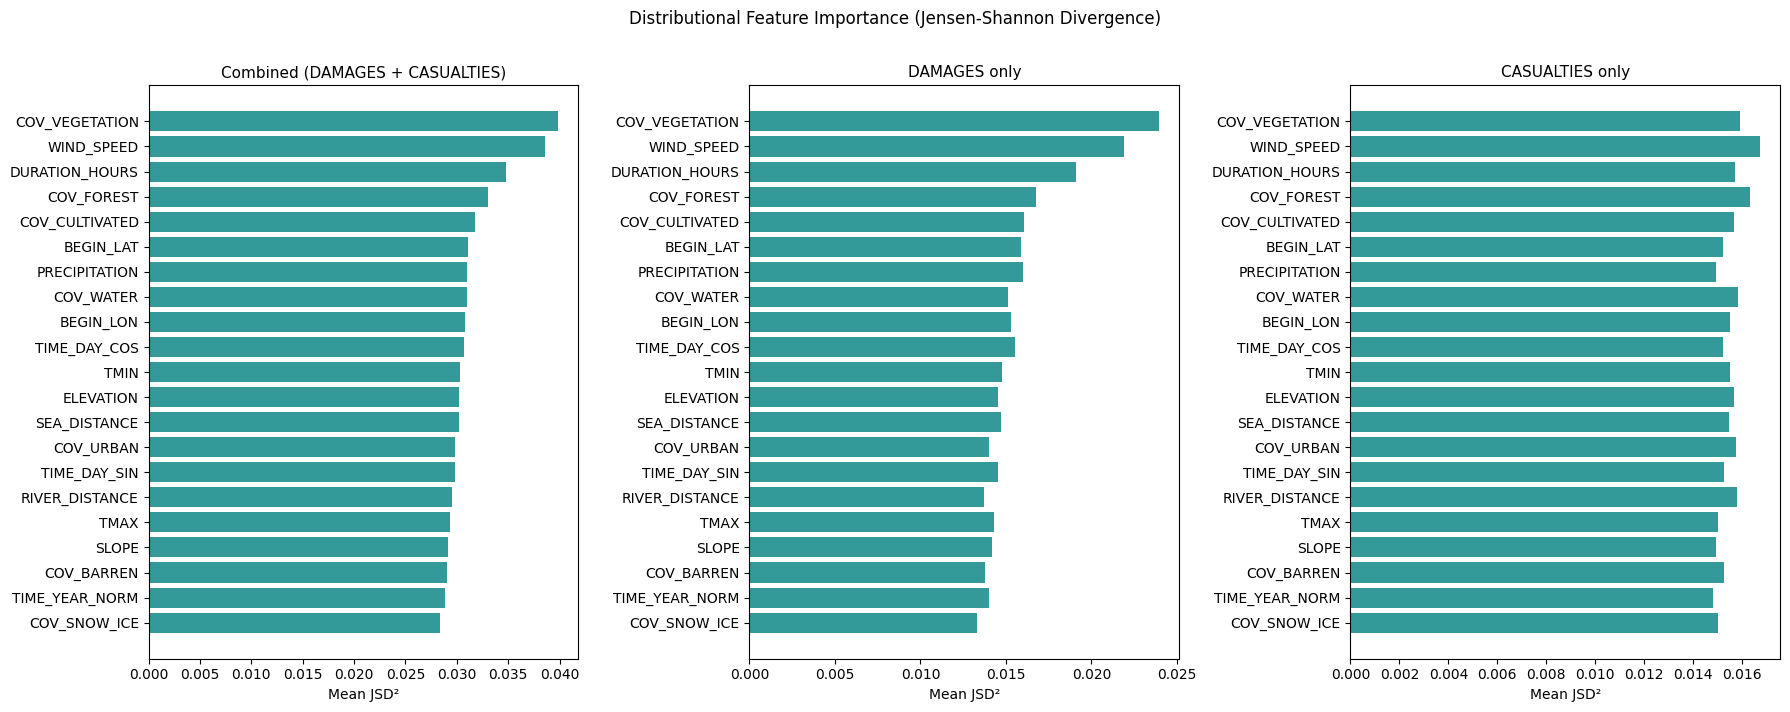

In [ ]:
_,_,_ = distributional_importance(flow, X_test, X_COLS, device)

# Drought

Model moved to cuda


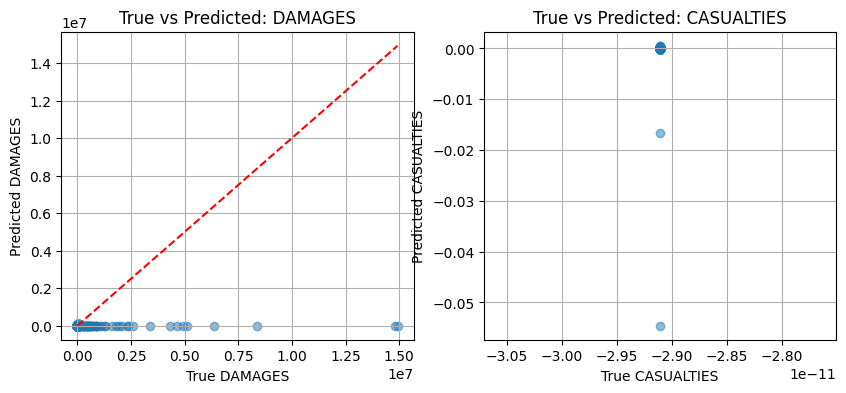

In [ ]:
EVENT_GROUP = 'Drought'
RUN_PATH = Path(f"../runs/best_flow_{EVENT_GROUP.lower()}.pt")

df = event_group_dfs[EVENT_GROUP]

X = df[X_COLS].values.astype(np.float32)
Y = df[TARGET_COLS].values.astype(np.float32)

# targets log transformation
Y = np.log1p(Y)

# train-val-test split
X_train, X_temp, Y_train, Y_temp = train_test_split(X, Y, test_size=0.3, random_state=42)

X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, random_state=42)

# standardize features and targets
x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train = x_scaler.fit_transform(X_train)
X_val   = x_scaler.transform(X_val)
X_test  = x_scaler.transform(X_test)

Y_train = y_scaler.fit_transform(Y_train)
Y_val   = y_scaler.transform(Y_val)
Y_test  = y_scaler.transform(Y_test)

# conversion to tensors
X_train = torch.tensor(X_train)
Y_train = torch.tensor(Y_train)

X_val = torch.tensor(X_val)
Y_val = torch.tensor(Y_val)

X_test = torch.tensor(X_test)
Y_test = torch.tensor(Y_test)

# data loaders
train_ds = TensorDataset(X_train, Y_train)
val_ds   = TensorDataset(X_val, Y_val)
test_ds   = TensorDataset(X_val, Y_val)
test_loader= DataLoader(test_ds, batch_size=BATCH_SIZE)

# Load model weights
flow.load_state_dict(torch.load(RUN_PATH, weights_only=True))
flow.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
flow = flow.to(device)
print(f"Model moved to {device}")

# Print prediction vs ground truth
utils.run_inference_and_plot(flow, test_loader, y_scaler, TARGET_COLS, device)

## Feature importance analysis

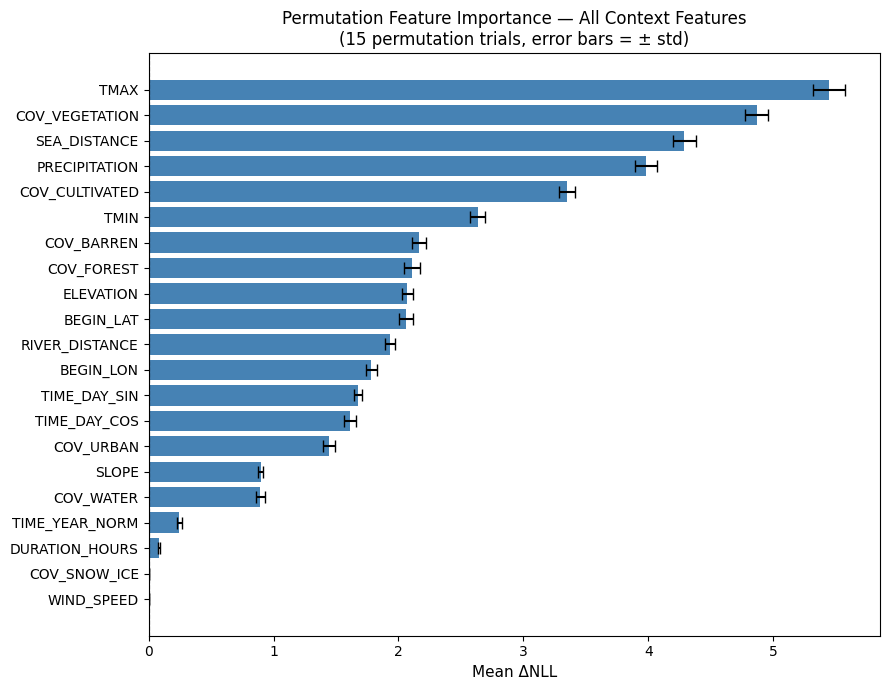

In [ ]:
drought_means, drought_stds = permutation_importance_full(flow, X_test, Y_test, X_COLS, device)

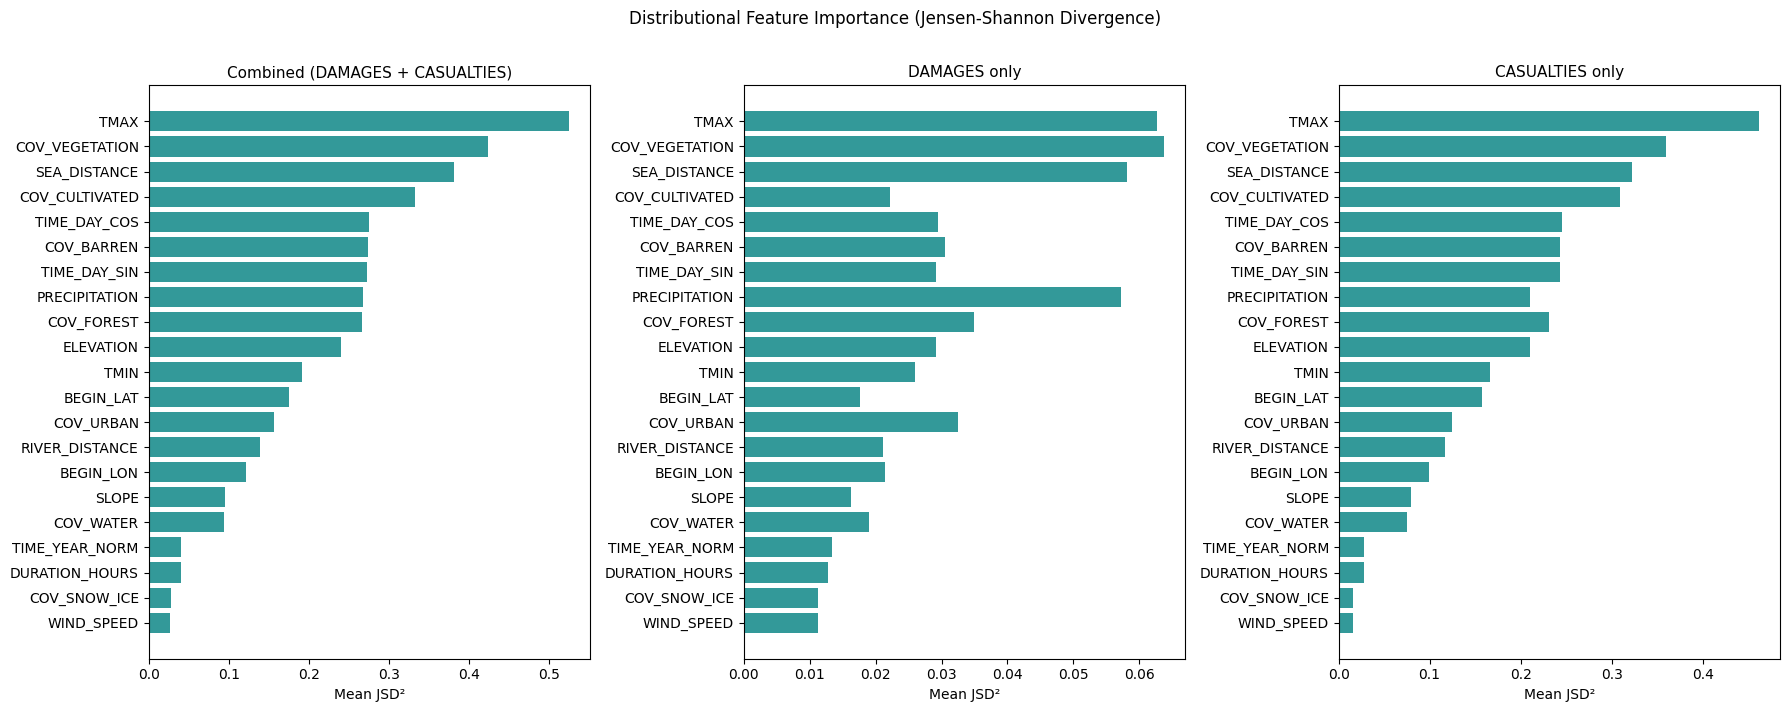

In [ ]:
_,_,_ = distributional_importance(flow, X_test, X_COLS, device)

# Wildfire

Model moved to cuda


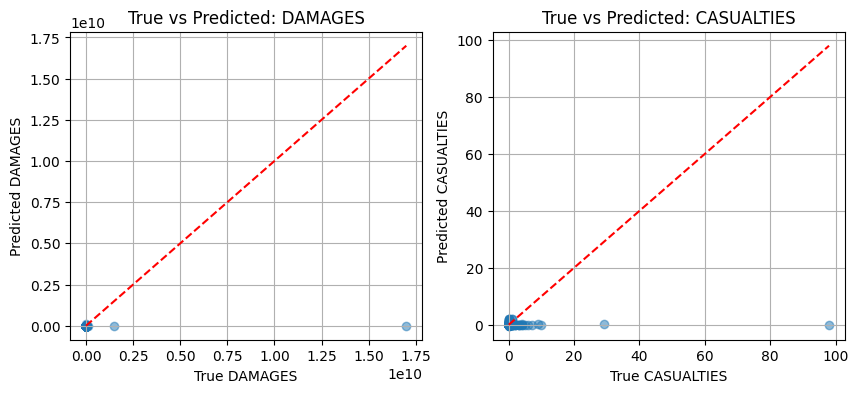

In [ ]:
EVENT_GROUP = 'Wildfire'
RUN_PATH = Path(f"../runs/flow_{EVENT_GROUP.lower()}.pt")

df = event_group_dfs[EVENT_GROUP]

X = df[X_COLS].values.astype(np.float32)
Y = df[TARGET_COLS].values.astype(np.float32)

# targets log transformation
Y = np.log1p(Y)

# train-val-test split
X_train, X_temp, Y_train, Y_temp = train_test_split(X, Y, test_size=0.3, random_state=42)

X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, random_state=42)

# standardize features and targets
x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train = x_scaler.fit_transform(X_train)
X_val   = x_scaler.transform(X_val)
X_test  = x_scaler.transform(X_test)

Y_train = y_scaler.fit_transform(Y_train)
Y_val   = y_scaler.transform(Y_val)
Y_test  = y_scaler.transform(Y_test)

# conversion to tensors
X_train = torch.tensor(X_train)
Y_train = torch.tensor(Y_train)

X_val = torch.tensor(X_val)
Y_val = torch.tensor(Y_val)

X_test = torch.tensor(X_test)
Y_test = torch.tensor(Y_test)

# data loaders
train_ds = TensorDataset(X_train, Y_train)
val_ds   = TensorDataset(X_val, Y_val)
test_ds   = TensorDataset(X_val, Y_val)
test_loader= DataLoader(test_ds, batch_size=BATCH_SIZE)

# Load model weights
flow.load_state_dict(torch.load(RUN_PATH, weights_only=True))
flow.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
flow = flow.to(device)
print(f"Model moved to {device}")

# Print prediction vs ground truth
utils.run_inference_and_plot(flow, test_loader, y_scaler, TARGET_COLS, device)

## Feature importance analysis

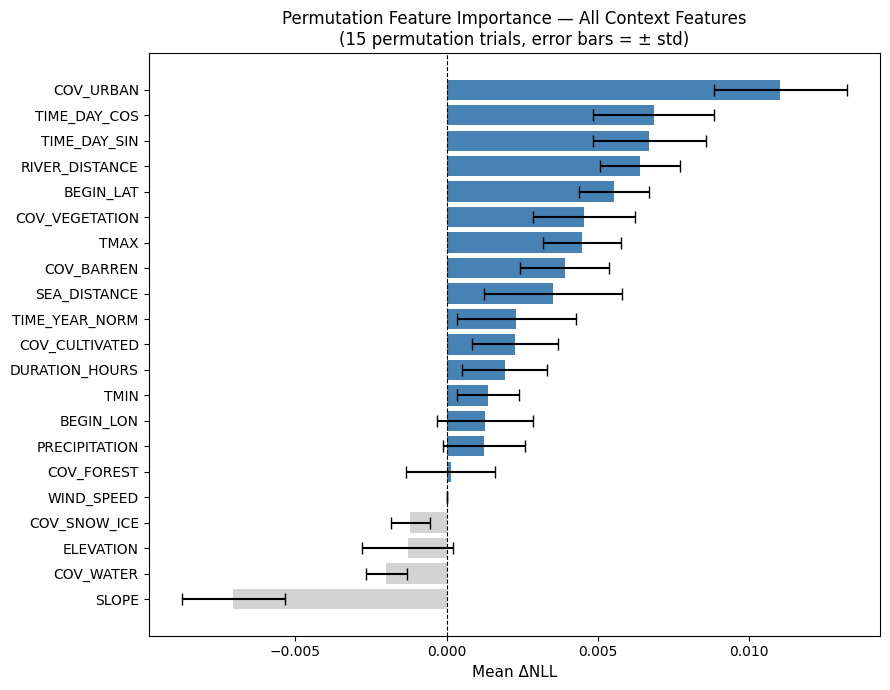

In [ ]:
wildfire_means, wildfire_stds = permutation_importance_full(flow, X_test, Y_test, X_COLS, device)

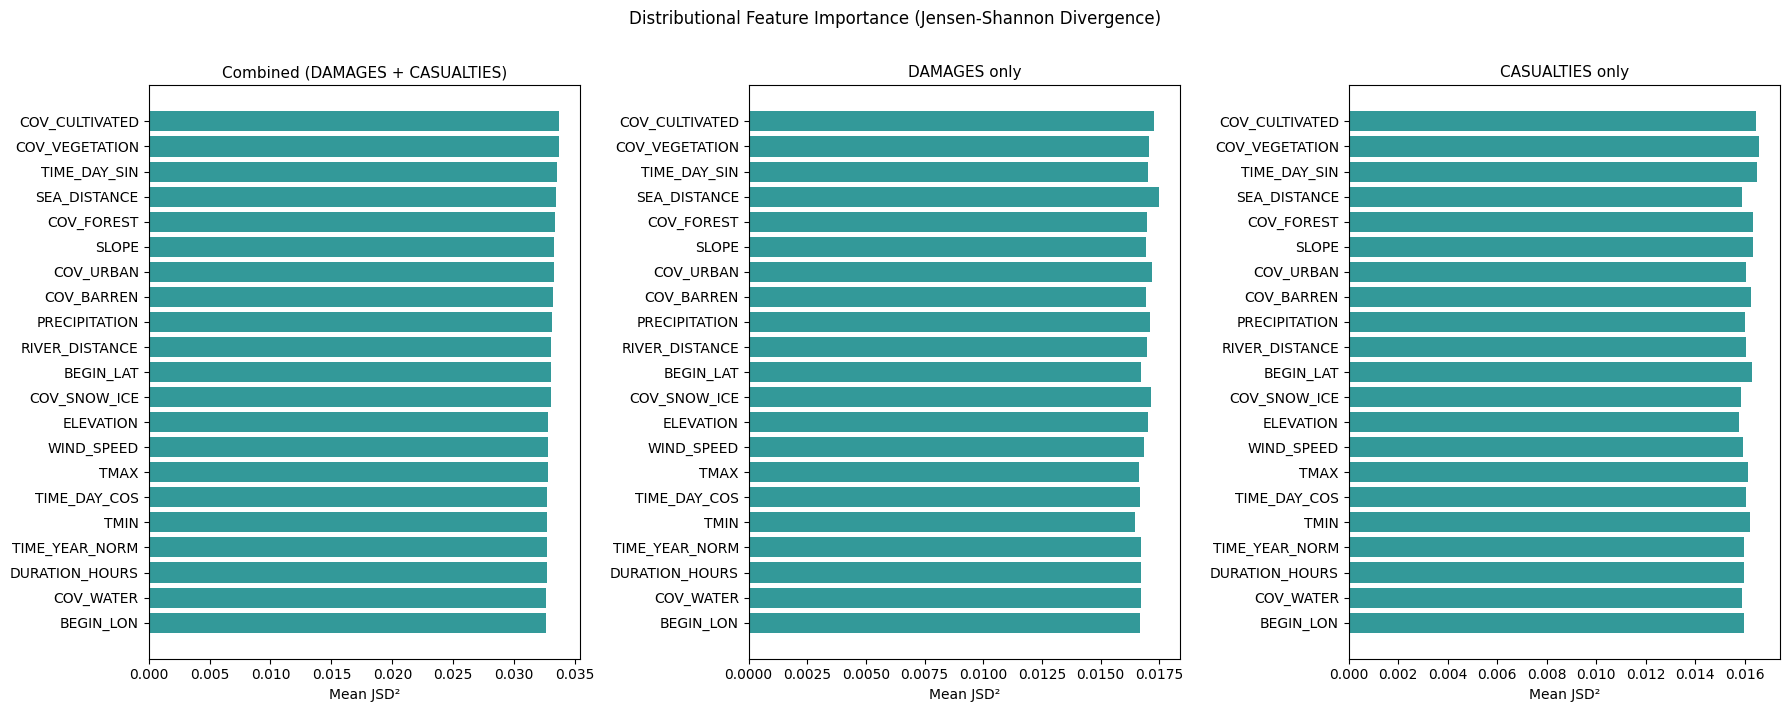

In [ ]:
_,_,_ = distributional_importance(flow, X_test, X_COLS, device)

# Avalanche

Model moved to cuda


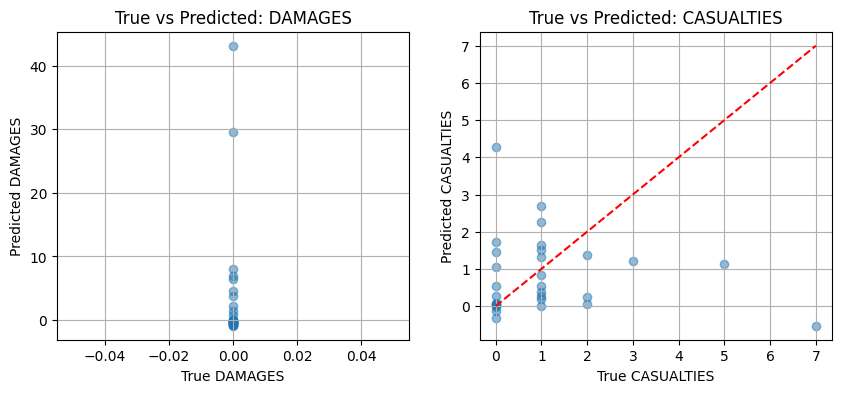

In [ ]:
EVENT_GROUP = 'Avalanche'
RUN_PATH = Path(f"../runs/flow_{EVENT_GROUP.lower()}.pt")

df = event_group_dfs[EVENT_GROUP]

X = df[X_COLS].values.astype(np.float32)
Y = df[TARGET_COLS].values.astype(np.float32)

# targets log transformation
Y = np.log1p(Y)

# train-val-test split
X_train, X_temp, Y_train, Y_temp = train_test_split(X, Y, test_size=0.3, random_state=42)

X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, random_state=42)

# standardize features and targets
x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train = x_scaler.fit_transform(X_train)
X_val   = x_scaler.transform(X_val)
X_test  = x_scaler.transform(X_test)

Y_train = y_scaler.fit_transform(Y_train)
Y_val   = y_scaler.transform(Y_val)
Y_test  = y_scaler.transform(Y_test)

# conversion to tensors
X_train = torch.tensor(X_train)
Y_train = torch.tensor(Y_train)

X_val = torch.tensor(X_val)
Y_val = torch.tensor(Y_val)

X_test = torch.tensor(X_test)
Y_test = torch.tensor(Y_test)

# data loaders
train_ds = TensorDataset(X_train, Y_train)
val_ds   = TensorDataset(X_val, Y_val)
test_ds   = TensorDataset(X_val, Y_val)
test_loader= DataLoader(test_ds, batch_size=BATCH_SIZE)

# Load model weights
flow.load_state_dict(torch.load(RUN_PATH, weights_only=True))
flow.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
flow = flow.to(device)
print(f"Model moved to {device}")

# Print prediction vs ground truth
utils.run_inference_and_plot(flow, test_loader, y_scaler, TARGET_COLS, device)

## Feature importance analysis

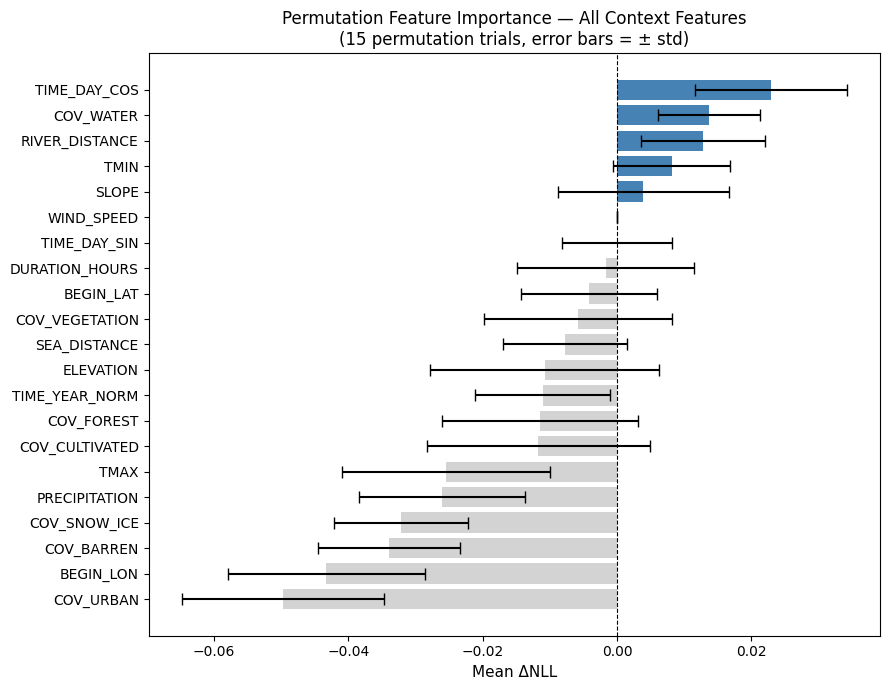

In [ ]:
avalanche_means, avalanche_stds = permutation_importance_full(flow, X_test, Y_test, X_COLS, device)

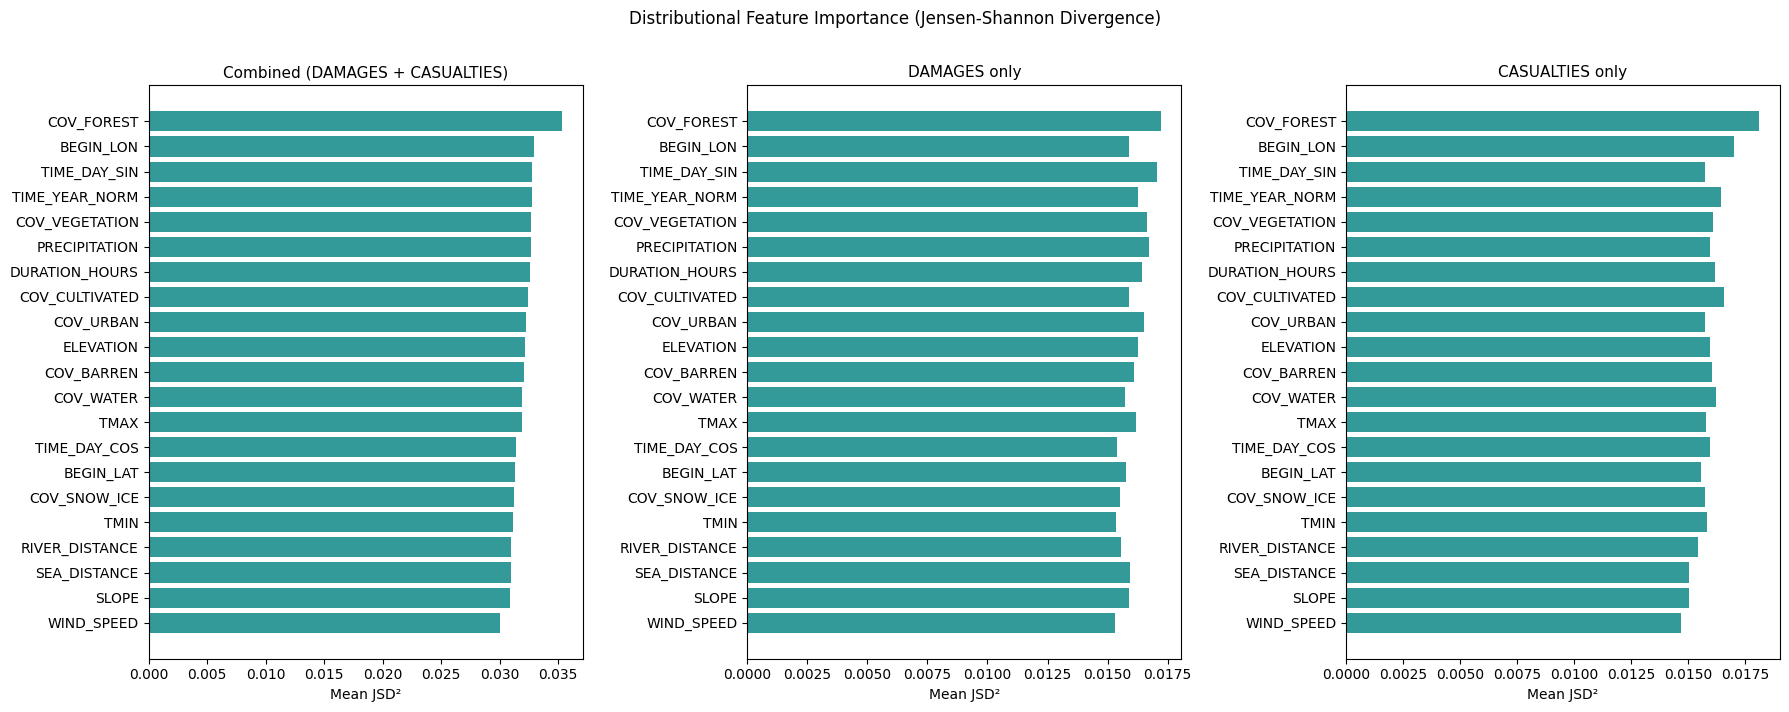

In [ ]:
_,_,_ = distributional_importance(flow, X_test, X_COLS, device, n_context=len(X_test))

# Freeze

Model moved to cuda


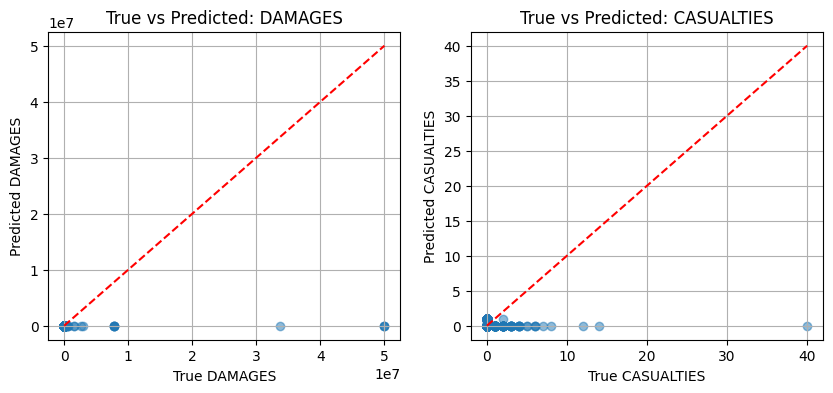

In [ ]:
EVENT_GROUP = 'Freeze'
RUN_PATH = Path(f"../runs/best_flow_{EVENT_GROUP.lower()}.pt")

df = event_group_dfs[EVENT_GROUP]

X = df[X_COLS].values.astype(np.float32)
Y = df[TARGET_COLS].values.astype(np.float32)

# targets log transformation
Y = np.log1p(Y)

# train-val-test split
X_train, X_temp, Y_train, Y_temp = train_test_split(X, Y, test_size=0.3, random_state=42)

X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, random_state=42)

# standardize features and targets
x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train = x_scaler.fit_transform(X_train)
X_val   = x_scaler.transform(X_val)
X_test  = x_scaler.transform(X_test)

Y_train = y_scaler.fit_transform(Y_train)
Y_val   = y_scaler.transform(Y_val)
Y_test  = y_scaler.transform(Y_test)

# conversion to tensors
X_train = torch.tensor(X_train)
Y_train = torch.tensor(Y_train)

X_val = torch.tensor(X_val)
Y_val = torch.tensor(Y_val)

X_test = torch.tensor(X_test)
Y_test = torch.tensor(Y_test)

# data loaders
train_ds = TensorDataset(X_train, Y_train)
val_ds   = TensorDataset(X_val, Y_val)
test_ds   = TensorDataset(X_val, Y_val)
test_loader= DataLoader(test_ds, batch_size=BATCH_SIZE)

# Load model weights
flow.load_state_dict(torch.load(RUN_PATH, weights_only=True))
flow.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
flow = flow.to(device)
print(f"Model moved to {device}")

# Print prediction vs ground truth
utils.run_inference_and_plot(flow, test_loader, y_scaler, TARGET_COLS, device)

## Feature importance analysis

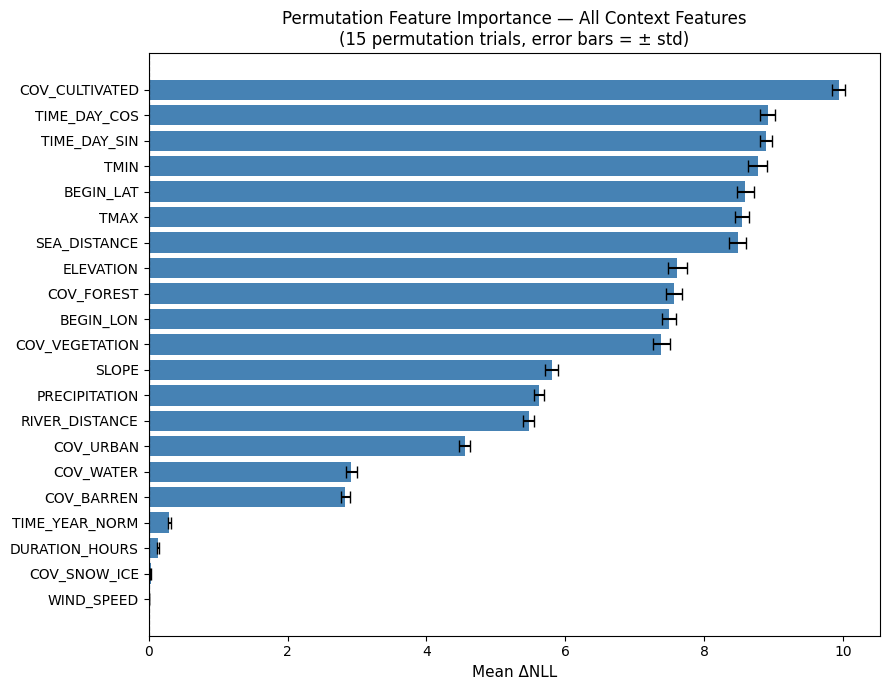

In [ ]:
freeze_means, freeze_stds = permutation_importance_full(flow, X_test, Y_test, X_COLS, device)

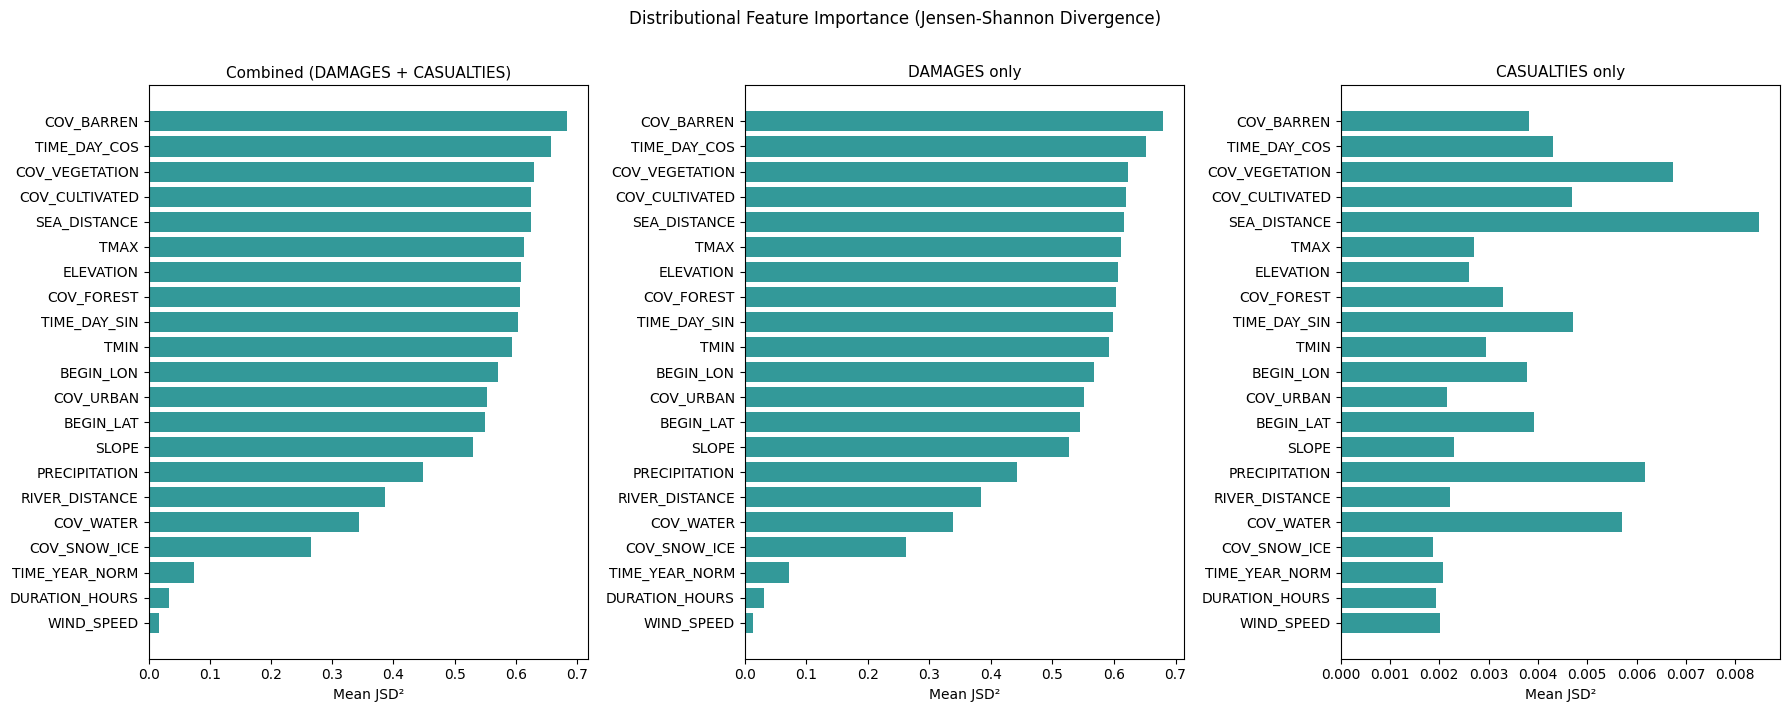

In [ ]:
_,_,_ = distributional_importance(flow, X_test, X_COLS, device)

# Heat

Model moved to cuda


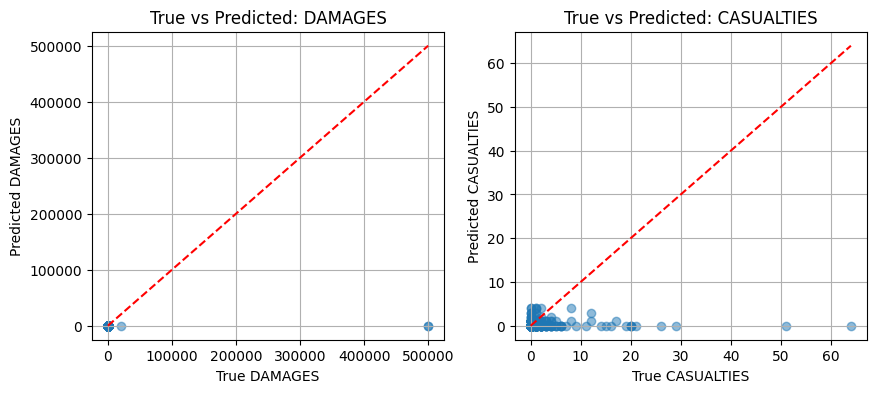

In [ ]:
EVENT_GROUP = 'Heat'
RUN_PATH = Path(f"../runs/best_flow_{EVENT_GROUP.lower()}.pt")

df = event_group_dfs[EVENT_GROUP]

X = df[X_COLS].values.astype(np.float32)
Y = df[TARGET_COLS].values.astype(np.float32)

# targets log transformation
Y = np.log1p(Y)

# train-val-test split
X_train, X_temp, Y_train, Y_temp = train_test_split(X, Y, test_size=0.3, random_state=42)

X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, random_state=42)

# standardize features and targets
x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train = x_scaler.fit_transform(X_train)
X_val   = x_scaler.transform(X_val)
X_test  = x_scaler.transform(X_test)

Y_train = y_scaler.fit_transform(Y_train)
Y_val   = y_scaler.transform(Y_val)
Y_test  = y_scaler.transform(Y_test)

# conversion to tensors
X_train = torch.tensor(X_train)
Y_train = torch.tensor(Y_train)

X_val = torch.tensor(X_val)
Y_val = torch.tensor(Y_val)

X_test = torch.tensor(X_test)
Y_test = torch.tensor(Y_test)

# data loaders
train_ds = TensorDataset(X_train, Y_train)
val_ds   = TensorDataset(X_val, Y_val)
test_ds   = TensorDataset(X_val, Y_val)
test_loader= DataLoader(test_ds, batch_size=BATCH_SIZE)

# Load model weights
flow.load_state_dict(torch.load(RUN_PATH, weights_only=True))
flow.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
flow = flow.to(device)
print(f"Model moved to {device}")

# Print prediction vs ground truth
utils.run_inference_and_plot(flow, test_loader, y_scaler, TARGET_COLS, device)

## Feature importance analysis

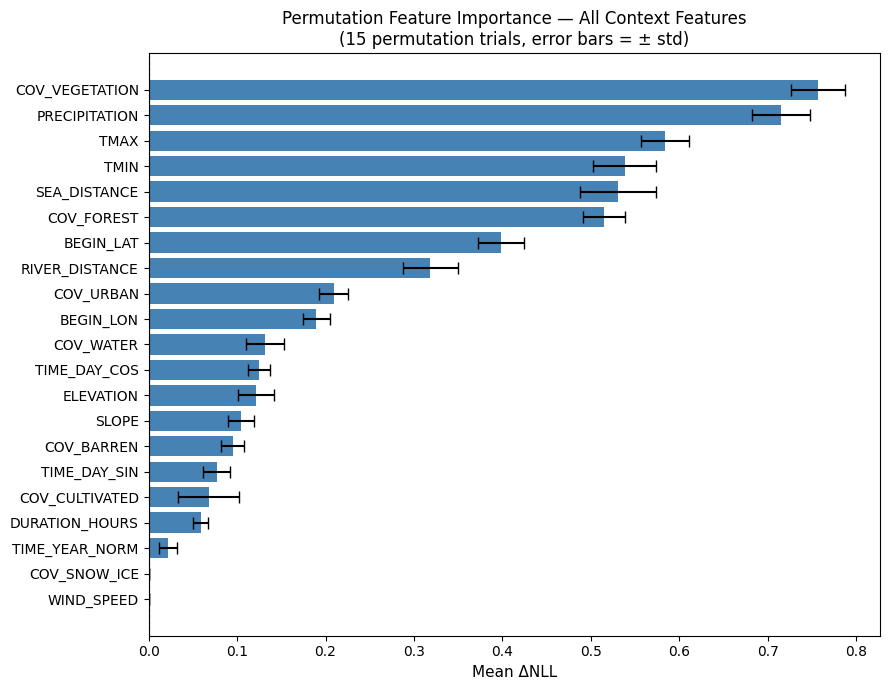

In [ ]:
heat_means, heat_stds = permutation_importance_full(flow, X_test, Y_test, X_COLS, device)

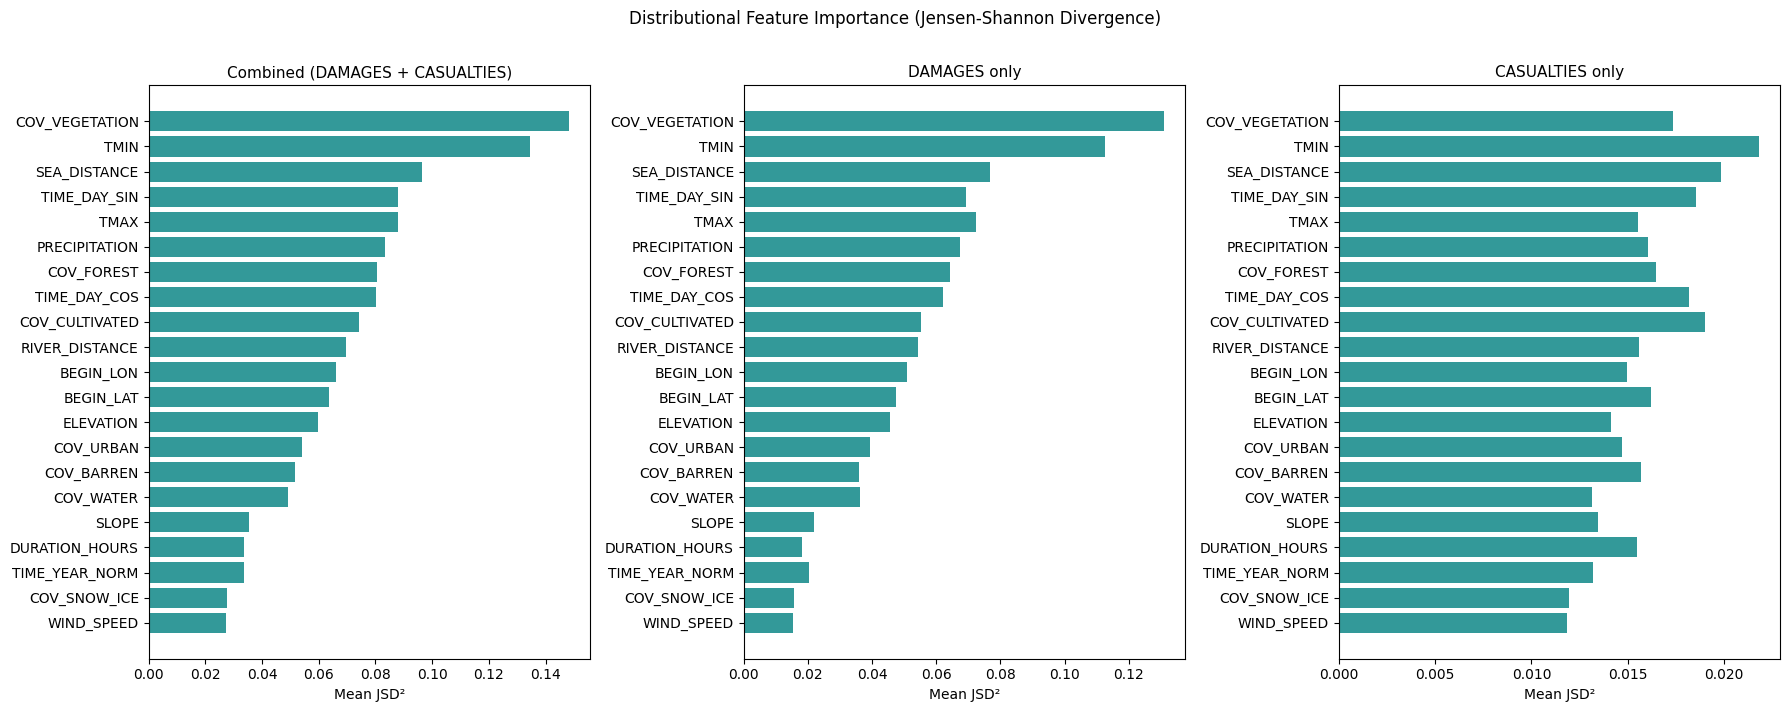

In [ ]:
_,_,_ = distributional_importance(flow, X_test, X_COLS, device)